# 11 - Shading diagnostics and intrinsic PLR

This notebook combines the shading-diagnostic workflow and the intrinsic PLR sensitivity workflow.

The purpose is to test whether high apparent PLR values are partly influenced by reversible operational effects, especially recurrent shading. The notebook first visualises module-specific diurnal suppression relative to Module 2, then uses a single-diode model and fault-classification workflow to identify non-normal operating bins in the sunny-day dataset.

The final output is an F0-only intrinsic PLR diagnostic, calculated only for modules with sufficient F0 monthly support.

The main outputs are:

1. annual diurnal \(P_\mathrm{mpp}\) ratio heatmaps relative to Module 2 for 2017-2021
2. selected fleet-relative current profiles for autumn and winter 2021
3. measured versus single-diode simulated outputs for Modules 2 and 10
4. fault-class fractions by module
5. temporal evolution of F0 and fault-candidate fractions for Module 10
6. F0-only intrinsic SLR PLR estimates
7. comparison between primary apparent PLR and F0-only intrinsic PLR

## 1. Imports and plotting style

In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from IPython.display import display

import statsmodels.api as sm

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,

    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",

    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    "legend.fontsize": 11,
    "legend.title_fontsize": 11,

    "axes.grid": True,
    "grid.alpha": 0.22,
    "grid.linewidth": 0.7,
})

TITLE_SIZE = 16
SUBTITLE_SIZE = 12
AXIS_LABEL_SIZE = 12
LEGEND_SIZE = 11

## 2. Paths and constants

In [2]:
PROJECT_ROOT = Path("C:/Users/amina/Thesis/Final Pipeline")

DATA_PROCESSED_DIR = PROJECT_ROOT / "data_processed"
DATA_INTERMEDIATE_DIR = PROJECT_ROOT / "data_intermediate"

FINAL_FIG_DIR = PROJECT_ROOT / "figures" / "final figures"
FINAL_TABLE_DIR = PROJECT_ROOT / "tables" / "final tables"

OUTPUT_DIR = DATA_PROCESSED_DIR / "shading_intrinsic_outputs"
DATA_OUTPUT_DIR = OUTPUT_DIR / "data"

for folder in [FINAL_FIG_DIR, FINAL_TABLE_DIR, OUTPUT_DIR, DATA_OUTPUT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# Main row-level performance-metric datasets
G200_METRICS_PATH = DATA_PROCESSED_DIR / "df_g200_metrics.parquet"
SUNNY_METRICS_PATH = DATA_PROCESSED_DIR / "df_sunny_metrics.parquet"

# Irradiance QC output from Notebook 04
IRRADIANCE_QC_PATH = DATA_PROCESSED_DIR / "irradiance_qc" / "df_irradiance_qc.parquet"

# Optional primary ensemble result from Notebook 11
PRIMARY_ENSEMBLE_PATH = FINAL_TABLE_DIR / "primary_yoy_stl_ensemble_g200.csv"

print("g200 metrics:", G200_METRICS_PATH)
print("sunny metrics:", SUNNY_METRICS_PATH)
print("irradiance QC:", IRRADIANCE_QC_PATH)
print("primary ensemble:", PRIMARY_ENSEMBLE_PATH)
print("output folder:", OUTPUT_DIR)

g200 metrics: C:\Users\amina\Thesis\Final Pipeline\data_processed\df_g200_metrics.parquet
sunny metrics: C:\Users\amina\Thesis\Final Pipeline\data_processed\df_sunny_metrics.parquet
irradiance QC: C:\Users\amina\Thesis\Final Pipeline\data_processed\irradiance_qc\df_irradiance_qc.parquet
primary ensemble: C:\Users\amina\Thesis\Final Pipeline\tables\final tables\primary_yoy_stl_ensemble_g200.csv
output folder: C:\Users\amina\Thesis\Final Pipeline\data_processed\shading_intrinsic_outputs


In [3]:
MODULE_ORDER = list(range(1, 11))
REFERENCE_MODULE = 2
TARGET_MODULES_FOR_HEATMAP = [5, 6, 7, 8, 9, 10]

ANALYSIS_YEARS = [2017, 2018, 2019, 2020, 2021]

#both have a clear-sky day profile (suspected shading in autumn and winter, most prominent in 2021) 
CANDIDATE_DAYS = {
    "autumn_2021": pd.Timestamp("2021-08-31"),
    "winter_2021": pd.Timestamp("2021-02-12"),
}

MONTH_LABELS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

TYPE_COLORS = {
    "Reference": "#009E73",
    "PID/Reference": "#0072B2",
    "uCrack": "#D55E00",
    "Unknown": "#666666",
}

BLACK = "#111111"
DARK_GREY = "#555555"
GREY = "#BDBDBD"

# Heatmap limits for module-to-M2 power ratios
RATIO_VMIN = 0.70
RATIO_VMAX = 1.08

# Fleet-relative current plot
CURRENT_RATIO_YLIM = (0.0, 1.18)
UNDERPERFORMANCE_THRESHOLD = 0.90

# Intrinsic PLR aggregation rules
BIN_HOURS = 15 / 60
G_STC = 1000.0
MIN_BINS_DAY_INTRINSIC = 10
MIN_DAYS_MONTH_INTRINSIC = 10
MIN_MONTHS_FOR_INTRINSIC_SLR = 12

DAYS_PER_YEAR = 365.25
CONFIDENCE_LEVEL = 0.95
ALPHA = 1 - CONFIDENCE_LEVEL

# SDM constants
CELLS_IN_SERIES = 36
EG_REF = 1.121
DEG_DT = -0.0002677
IRRAD_REF = 1000.0
TEMP_REF = 25.0

# Fault-class settings
G_MIN_SDM = 200.0
MIN_BINS_FOR_DAILY_SIGMA = 5
SIGMA_SOURCE = "simulated"

CLASS_ORDER = [
    "F0",
    "F1",
    "F2",
    "F3",
    "F4",
    "F5",
    "SDM_FAILED",
    "THRESHOLD_FAILED",
    "UNCLASSIFIED",
]

FAULT_CLASSES_PLOT = ["F0", "F2", "F3", "F4", "F5"]

FAULT_COLORS = {
    "F0": "#009E73",
    "F1": "#56B4E9",
    "F2": "#D7301F",
    "F3": "#F47C2C",
    "F4": "#0072B2",
    "F5": "#AA4499",
    "SDM_FAILED": "#4D4D4D",
    "THRESHOLD_FAILED": "#999999",
    "UNCLASSIFIED": "#D9D9D9",
}

## 3. Helper functions

In [4]:
def save_fig(filename, fig=None):
    """
    Save a figure to the final thesis figure directory.
    """
    if fig is None:
        fig = plt.gcf()

    out_path = FINAL_FIG_DIR / filename
    fig.savefig(out_path, bbox_inches="tight", dpi=300)
    print("Saved:", out_path)


def normalise_type_label(value):
    """
    Normalise module type labels.
    """
    if pd.isna(value):
        return "Unknown"

    value_str = str(value).strip()

    if value_str in TYPE_COLORS:
        return value_str

    value_low = value_str.lower()

    if "pid" in value_low:
        return "PID/Reference"
    if "ucrack" in value_low or "microcrack" in value_low or "crack" in value_low:
        return "uCrack"
    if "ref" in value_low:
        return "Reference"

    return "Unknown"


def to_bool_series(series):
    """
    Convert mixed boolean/string flag columns to boolean.
    """
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False)

    return (
        series.astype(str)
        .str.strip()
        .str.lower()
        .isin(["true", "1", "yes", "y"])
    )


def strip_timezone(series):
    """
    Convert datetime series to timezone-naive timestamps where needed.
    """
    series = pd.to_datetime(series, errors="coerce")

    if getattr(series.dt, "tz", None) is not None:
        return series.dt.tz_convert(None)

    return series


def module_label(module_id, module_type):
    return f"M{int(module_id)} ({module_type})"


def type_legend_handles():
    return [
        Line2D(
            [0], [0],
            color=TYPE_COLORS["Reference"],
            linewidth=2.2,
            label="Reference",
        ),
        Line2D(
            [0], [0],
            color=TYPE_COLORS["PID/Reference"],
            linewidth=2.2,
            label="PID/Reference",
        ),
        Line2D(
            [0], [0],
            color=TYPE_COLORS["uCrack"],
            linewidth=2.2,
            label="uCrack",
        ),
    ]


def module_category_marker_handles():
    return [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="none",
            markersize=7,
            markerfacecolor=TYPE_COLORS["Reference"],
            markeredgecolor=BLACK,
            markeredgewidth=0.7,
            label="Reference",
        ),
        Line2D(
            [0], [0],
            marker="o",
            linestyle="none",
            markersize=7,
            markerfacecolor=TYPE_COLORS["PID/Reference"],
            markeredgecolor=BLACK,
            markeredgewidth=0.7,
            label="PID/Reference",
        ),
        Line2D(
            [0], [0],
            marker="o",
            linestyle="none",
            markersize=7,
            markerfacecolor=TYPE_COLORS["uCrack"],
            markeredgecolor=BLACK,
            markeredgewidth=0.7,
            label="uCrack",
        ),
    ]


def safe_ratio(numerator, denominator):
    denominator = denominator.replace(0, np.nan) if isinstance(denominator, pd.Series) else denominator

    return numerator / denominator

## 4. Load datasets and add daylight flags

The annual diurnal diagnostics use the g200 metrics dataset. Daylight filtering is added using the irradiance-QC file from Notebook 04, where `is_daylight_analysis_bin` identifies bins with sufficient clear-sky POA irradiance for daytime analysis.

In [5]:
if not G200_METRICS_PATH.exists():
    raise FileNotFoundError(f"Missing g200 metrics file: {G200_METRICS_PATH}")

if not SUNNY_METRICS_PATH.exists():
    raise FileNotFoundError(f"Missing sunny metrics file: {SUNNY_METRICS_PATH}")

if not IRRADIANCE_QC_PATH.exists():
    raise FileNotFoundError(f"Missing irradiance QC file: {IRRADIANCE_QC_PATH}")

g200_raw = pd.read_parquet(G200_METRICS_PATH)
sunny_raw = pd.read_parquet(SUNNY_METRICS_PATH)
irr_qc = pd.read_parquet(IRRADIANCE_QC_PATH)

print("g200:", g200_raw.shape)
print("sunny:", sunny_raw.shape)
print("irradiance QC:", irr_qc.shape)

g200: (2169614, 77)
sunny: (1264419, 77)
irradiance QC: (5519872, 35)


In [7]:
def prepare_datetime_columns(df_in):
    """
    Standardise datetime columns used in the diagnostics.
    """
    df_out = df_in.copy()

    for col in ["Datetime_Bin_Local", "Datetime_Bin_UTC", "Datetime_Local"]:
        if col in df_out.columns:
            df_out[col] = pd.to_datetime(df_out[col], errors="coerce")

    if "Date" in df_out.columns:
        df_out["Date"] = pd.to_datetime(df_out["Date"], errors="coerce").dt.tz_localize(None).dt.normalize()
    else:
        df_out["Date"] = strip_timezone(df_out["Datetime_Bin_Local"]).dt.normalize()

    if "Datetime_Bin_Local" in df_out.columns:
        local_time = strip_timezone(df_out["Datetime_Bin_Local"])
        df_out["Year"] = local_time.dt.year
        df_out["Month"] = local_time.dt.month
        df_out["Time_h"] = (
            local_time.dt.hour
            + local_time.dt.minute / 60
            + local_time.dt.second / 3600
        )

    return df_out


g200 = prepare_datetime_columns(g200_raw)
sunny = prepare_datetime_columns(sunny_raw)
irr_qc = prepare_datetime_columns(irr_qc)

if "Type" in g200.columns:
    g200["Type"] = g200["Type"].apply(normalise_type_label)

if "Type" in sunny.columns:
    sunny["Type"] = sunny["Type"].apply(normalise_type_label)

In [8]:
def add_daylight_flags(df_in, irr_qc_in):
    """
    Merge daylight-bin flags from the irradiance QC dataset.

    Preference:
    1. merge on Datetime_Bin_UTC if available in both datasets;
    2. otherwise merge on Datetime_Bin_Local.
    """
    df_out = df_in.copy()

    daylight_cols = [
        "is_daytime_solar",
        "is_daylight_analysis_bin",
        "G_POA_clear_sky",
        "solar_apparent_elevation_deg",
    ]

    existing_daylight_cols = [col for col in daylight_cols if col in irr_qc_in.columns]

    if "is_daylight_analysis_bin" in df_out.columns:
        df_out["is_daylight_analysis_bin"] = to_bool_series(df_out["is_daylight_analysis_bin"])
        return df_out

    if "Datetime_Bin_UTC" in df_out.columns and "Datetime_Bin_UTC" in irr_qc_in.columns:
        merge_key = "Datetime_Bin_UTC"
    elif "Datetime_Bin_Local" in df_out.columns and "Datetime_Bin_Local" in irr_qc_in.columns:
        merge_key = "Datetime_Bin_Local"
    else:
        raise KeyError(
            "Could not merge daylight flags. Need Datetime_Bin_UTC or Datetime_Bin_Local in both datasets."
        )

    flag_table = (
        irr_qc_in[[merge_key] + existing_daylight_cols]
        .drop_duplicates(subset=[merge_key])
        .copy()
    )

    df_out = df_out.merge(
        flag_table,
        on=merge_key,
        how="left",
        validate="many_to_one",
    )

    for flag_col in ["is_daytime_solar", "is_daylight_analysis_bin"]:
        if flag_col in df_out.columns:
            df_out[flag_col] = to_bool_series(df_out[flag_col])

    return df_out


g200 = add_daylight_flags(g200, irr_qc)
sunny = add_daylight_flags(sunny, irr_qc)

print("g200 daylight flag count:")
display(g200["is_daylight_analysis_bin"].value_counts(dropna=False))

print("sunny daylight flag count:")
display(sunny["is_daylight_analysis_bin"].value_counts(dropna=False))

g200 daylight flag count:


is_daylight_analysis_bin
True     2136276
False      33338
Name: count, dtype: int64

sunny daylight flag count:


is_daylight_analysis_bin
True     1245488
False      18931
Name: count, dtype: int64

## 5. Prepare binned shading-diagnostic dataset

Shading diagnostics are calculated on a common 15-minute bin basis. Only daylight analysis bins are retained. The binned dataset keeps one median value per module and 15-minute timestamp.

In [9]:
REQUIRED_G200_COLUMNS = [
    "Module_ID",
    "Type",
    "Datetime_Bin_Local",
    "Date",
    "Year",
    "Month",
    "Time_h",
    "G_POA",
    "P_MPP",
    "I_MPP",
    "V_MPP",
    "is_daylight_analysis_bin",
]

missing_cols = [col for col in REQUIRED_G200_COLUMNS if col not in g200.columns]

if missing_cols:
    raise KeyError(f"Missing required g200 columns: {missing_cols}")

for flag_col in ["metric_valid", "fleet_relative_valid"]:
    if flag_col in g200.columns:
        g200[f"{flag_col}_bool"] = to_bool_series(g200[flag_col])
    else:
        g200[f"{flag_col}_bool"] = True

g200_daylight = (
    g200
    .loc[g200["is_daylight_analysis_bin"] == True]
    .loc[g200["metric_valid_bool"] == True]
    .copy()
)

if "fleet_relative_valid_bool" in g200_daylight.columns:
    g200_daylight = g200_daylight.loc[g200_daylight["fleet_relative_valid_bool"] == True].copy()

binned_cols = [
    "G_POA",
    "P_MPP",
    "I_MPP",
    "V_MPP",
]

optional_binned_cols = [
    "P_MPP_rel_fleet",
    "I_MPP_rel_fleet",
    "V_MPP_rel_fleet",
    "PR_25C",
    "PR_25C_rel_fleet",
]

binned_cols += [col for col in optional_binned_cols if col in g200_daylight.columns]

binned_shading = (
    g200_daylight
    .dropna(subset=["Module_ID", "Datetime_Bin_Local", "P_MPP", "I_MPP"])
    .groupby(
        [
            "Module_ID",
            "Type",
            "Datetime_Bin_Local",
            "Date",
            "Year",
            "Month",
            "Time_h",
        ],
        as_index=False,
    )
    .agg({col: "median" for col in binned_cols})
    .sort_values(["Datetime_Bin_Local", "Module_ID"])
    .reset_index(drop=True)
)

print("Binned shading dataset:", binned_shading.shape)
print("Years:", sorted(binned_shading["Year"].dropna().unique()))
display(binned_shading.head())

Binned shading dataset: (295011, 16)
Years: [np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021)]


,Module_ID,Type,Datetime_Bin_Local,Date,Year,Month,Time_h,G_POA,P_MPP,I_MPP,V_MPP,P_MPP_rel_fleet,I_MPP_rel_fleet,V_MPP_rel_fleet,PR_25C,PR_25C_rel_fleet
0,1,PID/Reference,2017-01-02 10:15:00+01:00,2017-01-02,2017,1,9.25,228.473284,34.133574,1.756157,19.730978,1.048929,1.051807,1.015166,0.912971,1.037776
1,2,Reference,2017-01-02 10:15:00+01:00,2017-01-02,2017,1,9.25,230.327981,34.547454,1.711679,20.220414,1.061647,1.025168,1.040348,0.914698,1.039739
2,3,uCrack,2017-01-02 10:15:00+01:00,2017-01-02,2017,1,9.25,232.094945,25.159642,1.451308,17.344660,0.773159,0.869225,0.892389,0.660013,0.750239
3,4,uCrack,2017-01-02 10:15:00+01:00,2017-01-02,2017,1,9.25,226.319363,32.726399,1.684034,19.433338,1.005686,1.008610,0.999852,0.879033,0.999199
4,5,Reference,2017-01-02 10:15:00+01:00,2017-01-02,2017,1,9.25,227.207517,33.823010,1.740349,19.436270,1.039385,1.042339,1.000003,0.912992,1.037801


## 6. Annual diurnal \(P_\mathrm{mpp}\) ratios relative to Module 2

These heatmaps compare each selected module against Module 2 at the same 15-minute timestamps. Module 2 is used as the reference because it has consistently reference-like behaviour in the PLR results.

Only daylight analysis bins are used.

In [10]:
def black_missing_cmap(base_cmap_name="viridis"):
    """
    Use black for missing values in heatmaps.
    """
    cmap = plt.get_cmap(base_cmap_name).copy()
    cmap.set_bad(color="black")
    return cmap


def set_heatmap_hour_ticks(ax, hour_values, n_ticks=5):
    """
    Format heatmap x-axis from decimal-hour columns.
    """
    hour_values = list(hour_values)

    if len(hour_values) == 0:
        return

    tick_idx = np.linspace(0, len(hour_values) - 1, min(n_ticks, len(hour_values))).astype(int)

    tick_labels = []
    for idx in tick_idx:
        h = float(hour_values[idx])
        hour = int(np.floor(h))
        minute = int(round((h - hour) * 60))
        tick_labels.append(f"{hour:02d}:{minute:02d}")

    ax.set_xticks(tick_idx)
    ax.set_xticklabels(tick_labels)


def build_annual_module_ratio_matrix(
    binned_df,
    year,
    target_module,
    reference_module=REFERENCE_MODULE,
    metric_col="P_MPP",
):
    """
    Build month-by-time matrix of target/reference ratio for one year.
    """
    sub = binned_df.loc[binned_df["Year"] == int(year)].copy()

    ref = sub.loc[
        sub["Module_ID"] == reference_module,
        ["Datetime_Bin_Local", "Month", "Time_h", metric_col],
    ].copy()

    target = sub.loc[
        sub["Module_ID"] == target_module,
        ["Datetime_Bin_Local", metric_col],
    ].copy()

    if ref.empty or target.empty:
        return None, pd.DataFrame()

    merged = ref.merge(
        target,
        on="Datetime_Bin_Local",
        suffixes=(f"_M{reference_module}", f"_M{target_module}"),
    )

    merged["ratio"] = (
        merged[f"{metric_col}_M{target_module}"]
        / merged[f"{metric_col}_M{reference_module}"].replace(0, np.nan)
    )

    matrix = (
        merged
        .pivot_table(
            index="Month",
            columns="Time_h",
            values="ratio",
            aggfunc="median",
        )
        .reindex(range(1, 13))
    )

    return matrix, merged

In [11]:
def plot_annual_pmpp_ratio_grid(
    binned_df,
    year,
    target_modules=TARGET_MODULES_FOR_HEATMAP,
    reference_module=REFERENCE_MODULE,
    save=True,
):
    """
    Plot annual month-by-time P_mpp ratios for selected modules relative to Module 2.
    """
    fig, axes = plt.subplots(
        nrows=3,
        ncols=2,
        figsize=(12.8, 10.2),
        sharex=True,
        sharey=True,
    )

    axes = axes.flatten()

    im = None
    merged_tables = []

    for ax, target_module in zip(axes, target_modules):
        matrix, merged = build_annual_module_ratio_matrix(
            binned_df=binned_df,
            year=year,
            target_module=target_module,
            reference_module=reference_module,
            metric_col="P_MPP",
        )

        ax.set_facecolor("black")

        if matrix is None or matrix.empty:
            ax.text(
                0.5,
                0.5,
                "No data",
                ha="center",
                va="center",
                transform=ax.transAxes,
                color="white",
            )
            ax.set_title(
                rf"M{target_module}/M{reference_module} $P_\mathrm{{mpp}}$ ratio",
                fontsize=SUBTITLE_SIZE,
                pad=5,
            )
            continue

        masked_values = np.ma.masked_invalid(matrix.values.astype(float))

        im = ax.imshow(
            masked_values,
            aspect="auto",
            interpolation="nearest",
            cmap=black_missing_cmap("viridis"),
            vmin=RATIO_VMIN,
            vmax=RATIO_VMAX,
        )

        set_heatmap_hour_ticks(ax, matrix.columns, n_ticks=5)

        ax.set_yticks(np.arange(12))
        ax.set_yticklabels(MONTH_LABELS)

        ax.set_title(
            rf"M{target_module}/M{reference_module} $P_\mathrm{{mpp}}$ ratio",
            fontsize=SUBTITLE_SIZE,
            pad=5,
        )

        ax.grid(False)

        if merged is not None and not merged.empty:
            tmp = merged.copy()
            tmp["Year"] = int(year)
            tmp["target_module"] = int(target_module)
            tmp["reference_module"] = int(reference_module)
            merged_tables.append(tmp)

    fig.suptitle(
        rf"Annual diurnal $P_\mathrm{{mpp}}$ ratios relative to Module {reference_module}, {year}",
        fontsize=TITLE_SIZE,
        y=0.985,
    )

    fig.supxlabel("Time of day [h]", fontsize=AXIS_LABEL_SIZE, y=0.045)
    fig.supylabel("Month", fontsize=AXIS_LABEL_SIZE, x=0.035)

    if im is not None:
        cbar_ax = fig.add_axes([0.92, 0.18, 0.018, 0.66])
        cbar = fig.colorbar(im, cax=cbar_ax)
        cbar.set_label(
            rf"$P_\mathrm{{mpp}}$ ratio relative to M{reference_module} [-]",
            fontsize=AXIS_LABEL_SIZE,
        )

    fig.subplots_adjust(
        left=0.075,
        right=0.89,
        top=0.94,
        bottom=0.09,
        hspace=0.30,
        wspace=0.10,
    )

    if save:
        save_fig(f"shading_annual_pmpp_ratios_relative_to_m{reference_module}_{year}.png", fig)

    plt.show()

    if merged_tables:
        return fig, pd.concat(merged_tables, ignore_index=True)

    return fig, pd.DataFrame()

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\shading_annual_pmpp_ratios_relative_to_m2_2017.png


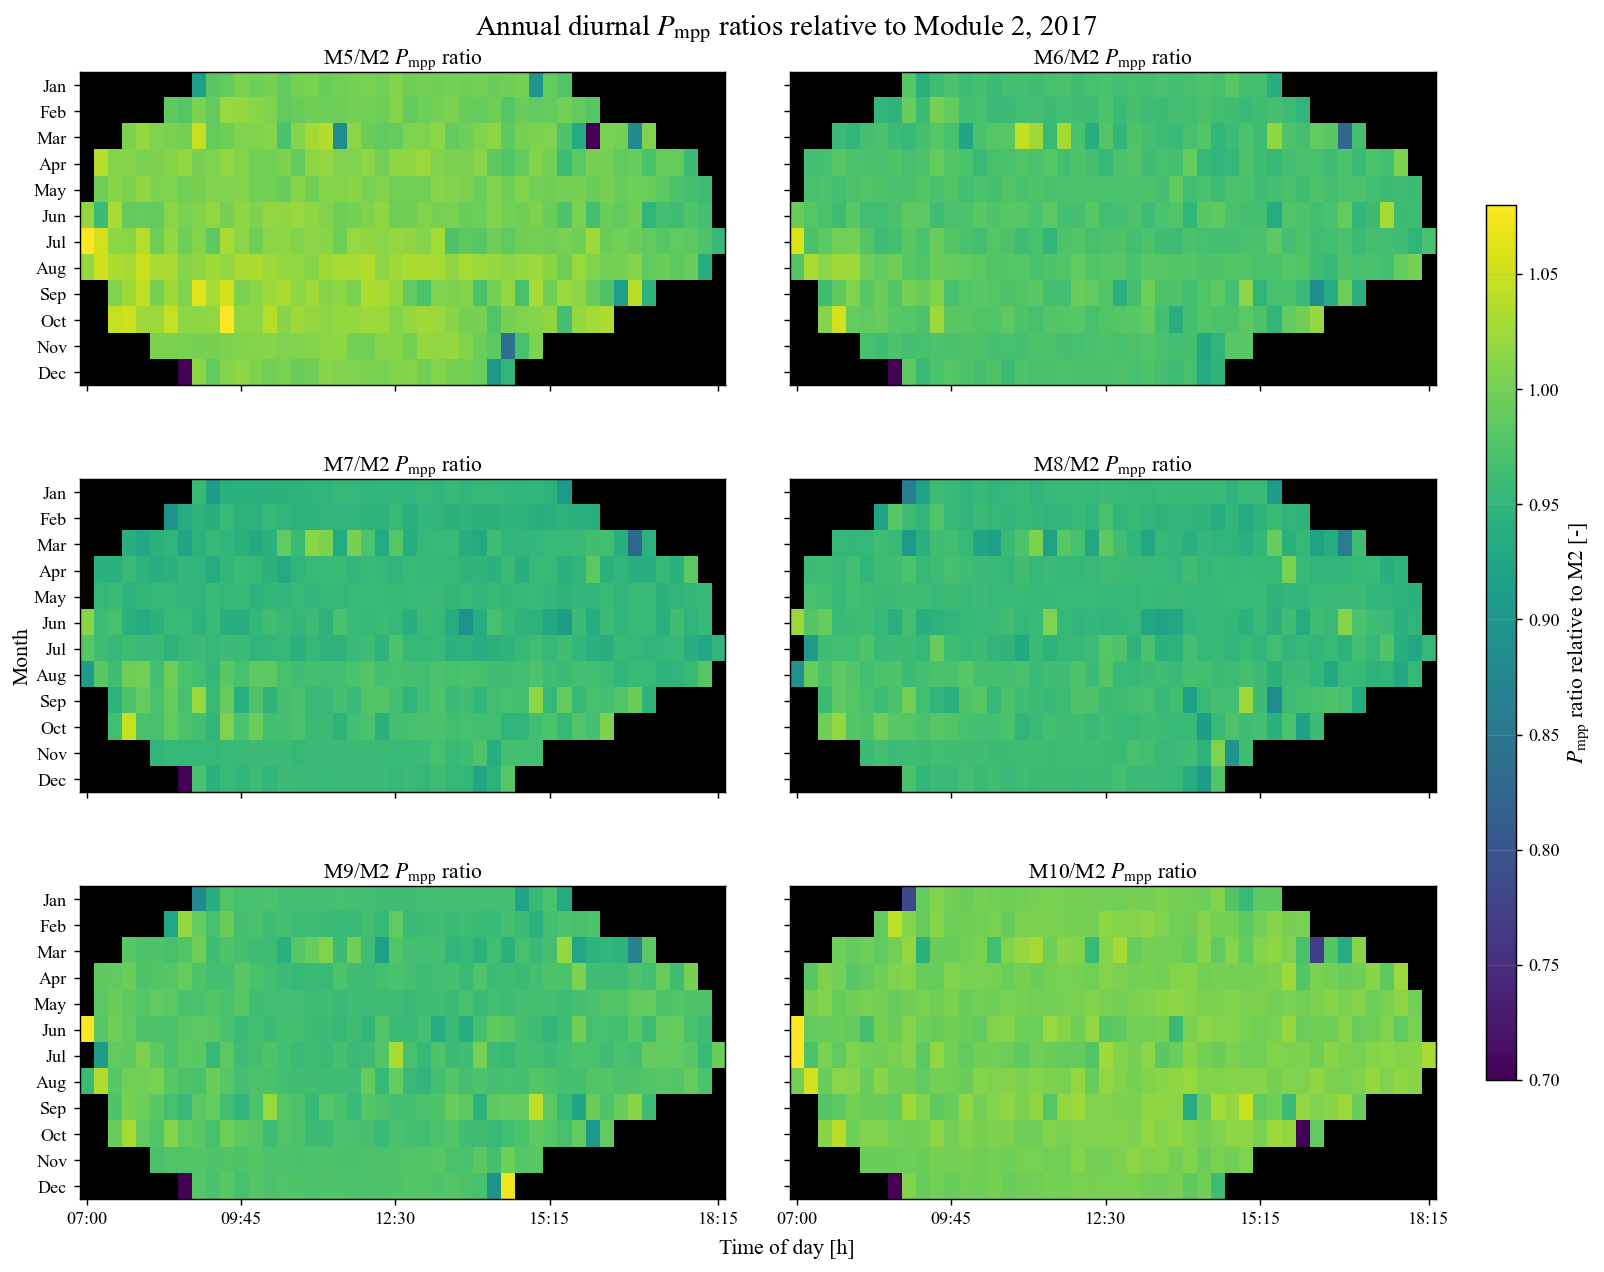

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\shading_annual_pmpp_ratios_relative_to_m2_2018.png


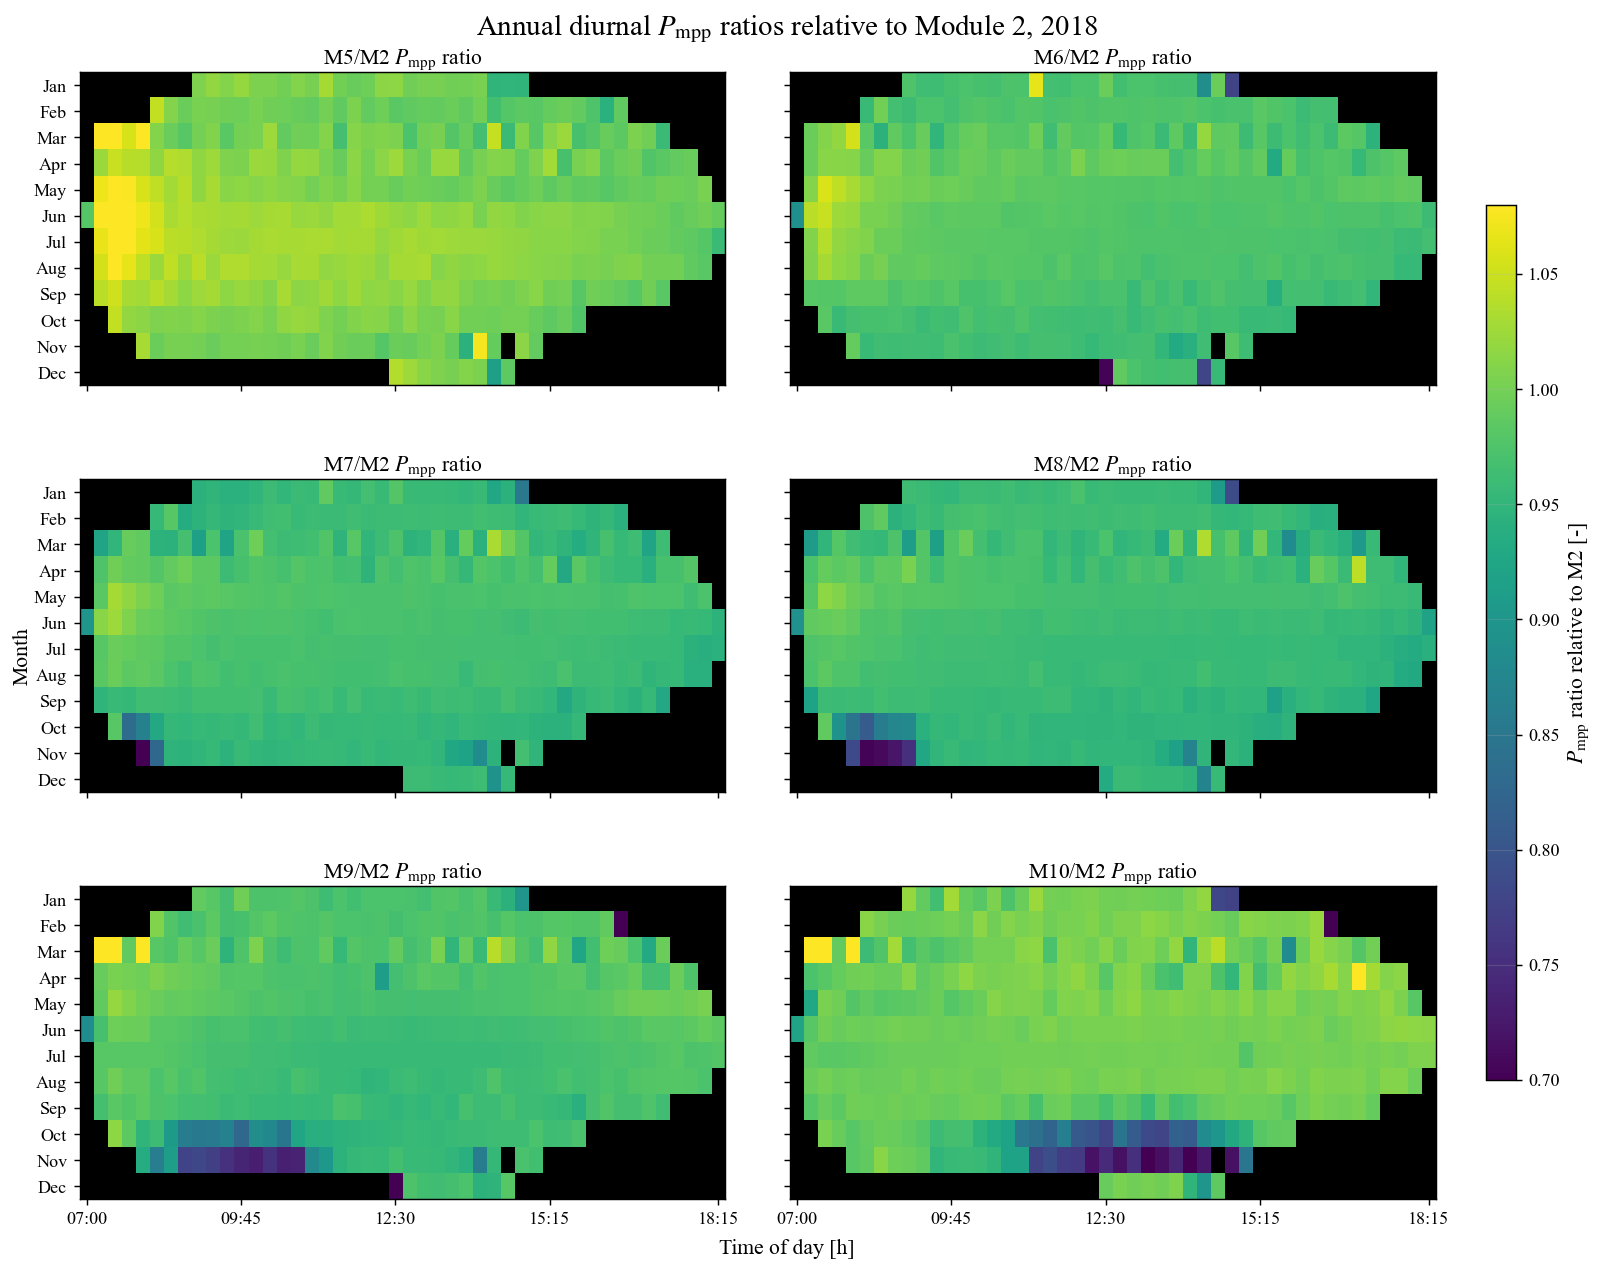

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\shading_annual_pmpp_ratios_relative_to_m2_2019.png


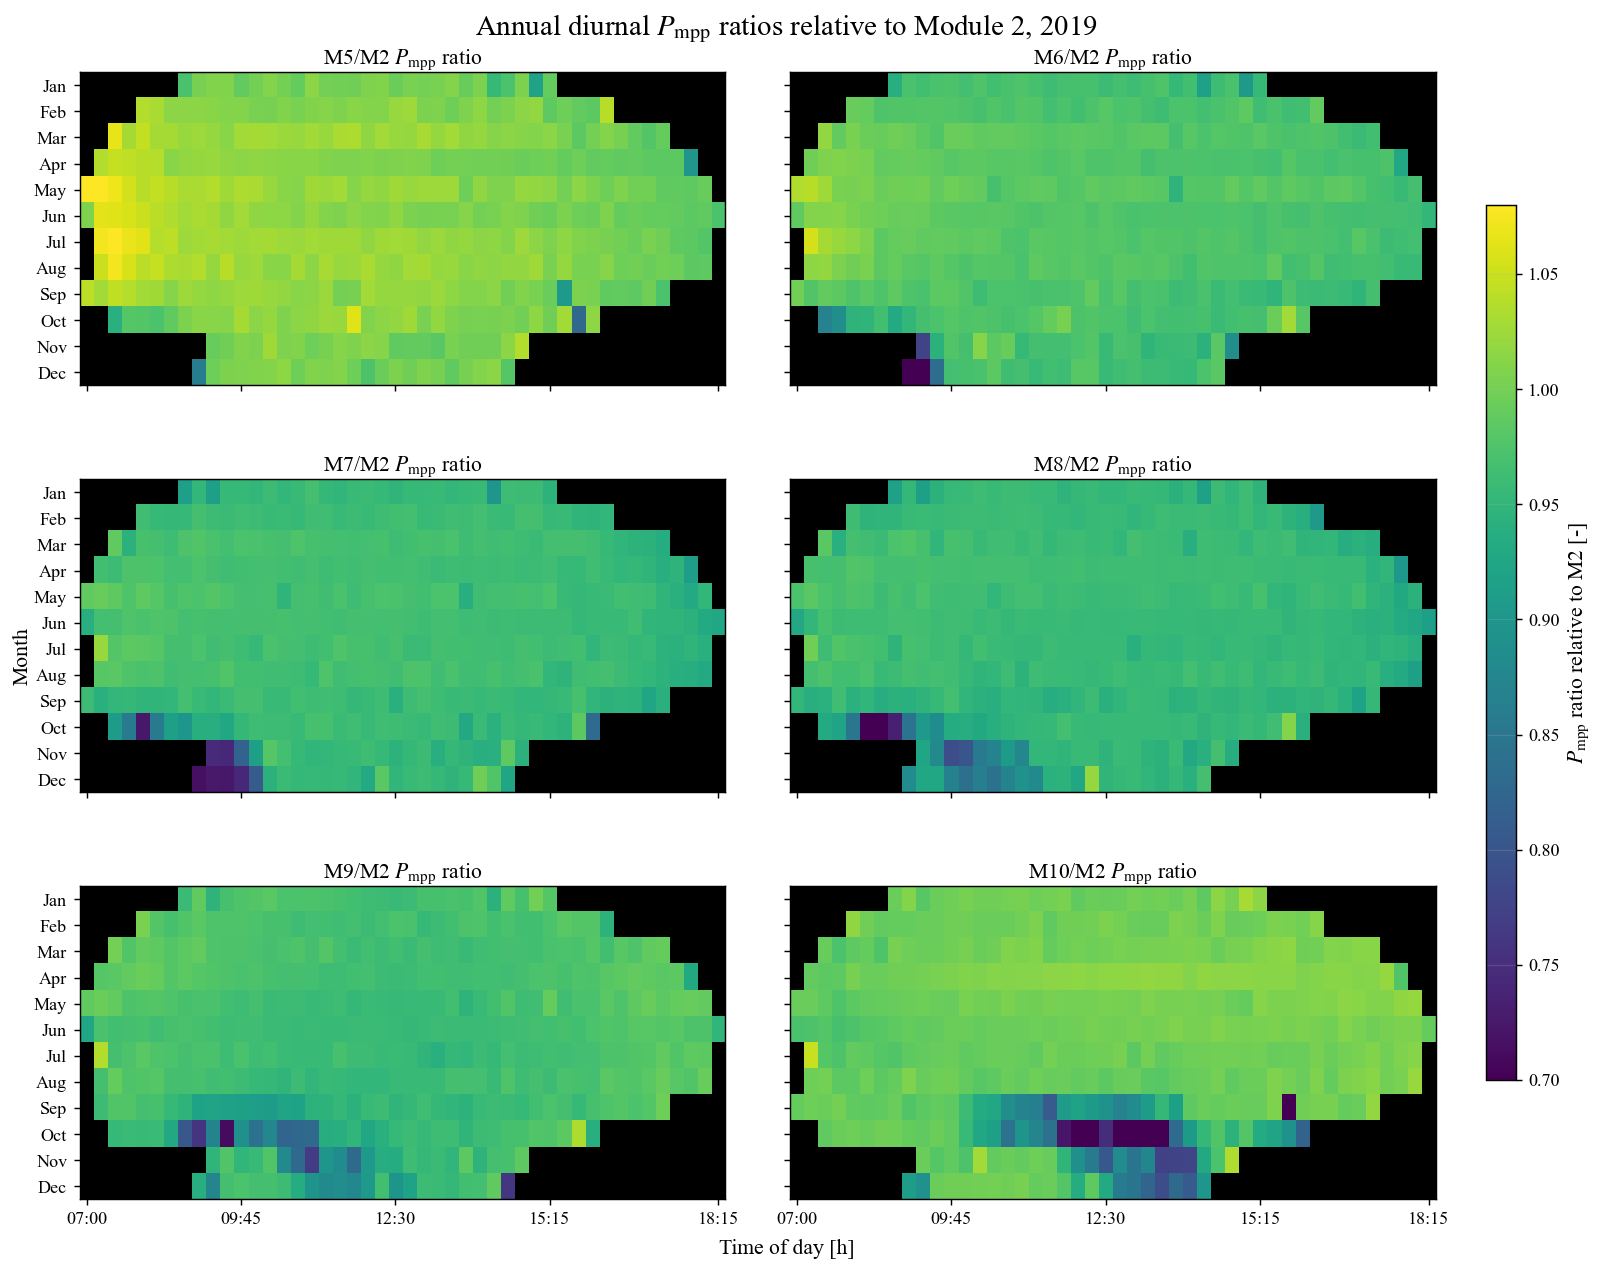

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\shading_annual_pmpp_ratios_relative_to_m2_2020.png


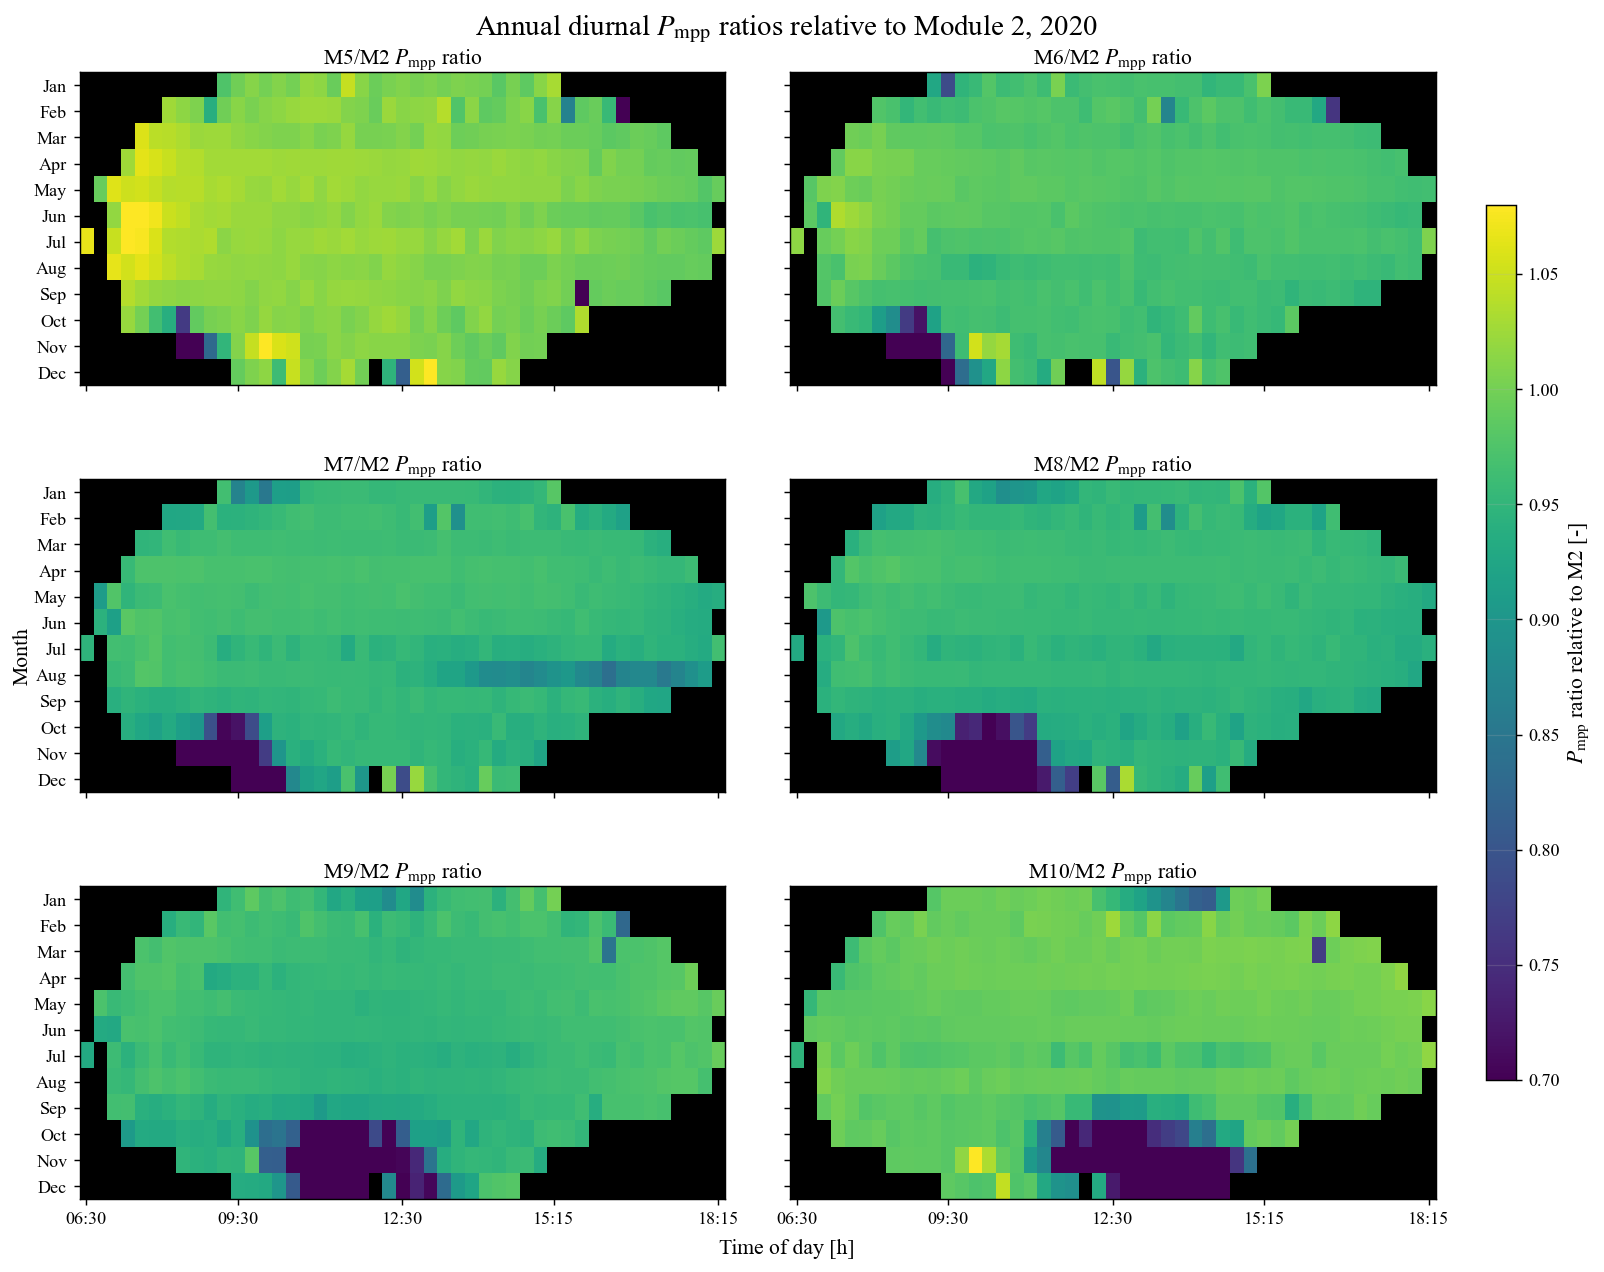

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\shading_annual_pmpp_ratios_relative_to_m2_2021.png


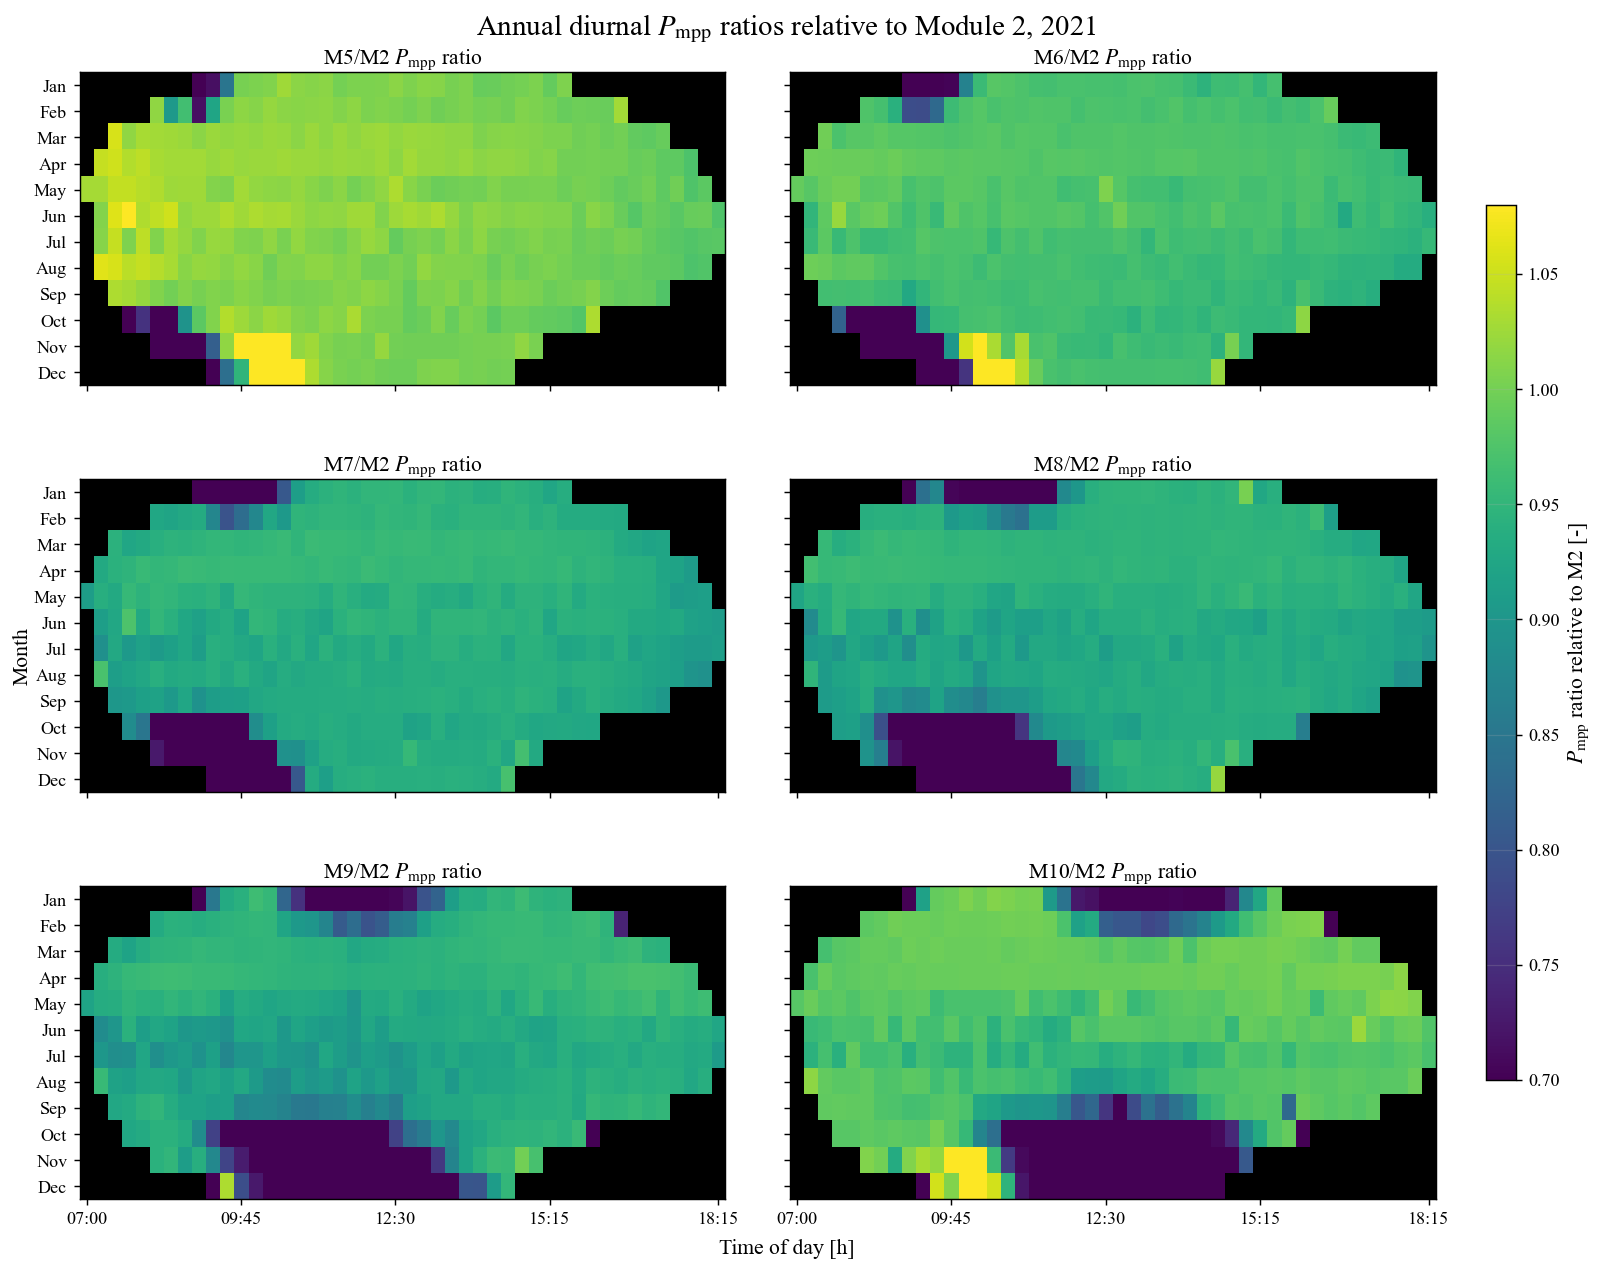

,Datetime_Bin_Local,Month,Time_h,P_MPP_M2,P_MPP_M5,ratio,Year,target_module,reference_module,P_MPP_M6,P_MPP_M7,P_MPP_M8,P_MPP_M9,P_MPP_M10
0,2017-01-02 10:15:00+01:00,1,9.25,34.547454,33.823010,0.979030,2017,5,2,NaN,NaN,NaN,NaN,NaN
1,2017-01-02 10:30:00+01:00,1,9.50,45.221949,45.699225,1.010554,2017,5,2,NaN,NaN,NaN,NaN,NaN
2,2017-01-02 10:45:00+01:00,1,9.75,57.215035,57.807980,1.010363,2017,5,2,NaN,NaN,NaN,NaN,NaN
3,2017-01-02 11:00:00+01:00,1,10.00,69.383129,68.927324,0.993431,2017,5,2,NaN,NaN,NaN,NaN,NaN
4,2017-01-02 11:15:00+01:00,1,10.25,68.959602,74.257868,1.076831,2017,5,2,NaN,NaN,NaN,NaN,NaN


In [12]:
annual_ratio_tables = []

for year in ANALYSIS_YEARS:
    fig, ratio_table = plot_annual_pmpp_ratio_grid(
        binned_df=binned_shading,
        year=year,
        save=True,
    )

    if not ratio_table.empty:
        annual_ratio_tables.append(ratio_table)

if annual_ratio_tables:
    annual_ratio_all = pd.concat(annual_ratio_tables, ignore_index=True)

    annual_ratio_all.to_csv(
        FINAL_TABLE_DIR / "shading_annual_pmpp_ratios_relative_to_m2_2017_2021.csv",
        index=False,
    )

    display(annual_ratio_all.head())

## 7. Selected fleet-relative current profiles

Fleet-relative current profiles are shown for selected clear diagnostic days. Current is used because partial shading is expected to affect current more directly than voltage.

Only the selected autumn and winter 2021 examples are exported.

In [13]:
def prepare_fleet_relative_current(df_in):
    """
    Ensure an I_MPP relative-to-fleet metric exists.
    """
    df_out = df_in.copy()

    if "I_MPP_rel_fleet" in df_out.columns:
        return df_out

    fleet_median = (
        df_out
        .groupby("Datetime_Bin_Local", as_index=False)
        .agg(I_MPP_fleet_median=("I_MPP", "median"))
    )

    df_out = df_out.merge(
        fleet_median,
        on="Datetime_Bin_Local",
        how="left",
        validate="many_to_one",
    )

    df_out["I_MPP_rel_fleet"] = (
        df_out["I_MPP"] / df_out["I_MPP_fleet_median"].replace(0, np.nan)
    )

    return df_out


binned_shading = prepare_fleet_relative_current(binned_shading)

In [15]:
def plot_fleet_relative_current_profiles(
    binned_df,
    day,
    label,
    save=True,
):
    """
    Plot per-module current profiles relative to fleet median for one day.
    """
    day = pd.Timestamp(day).normalize()

    day_df = (
        binned_df
        .loc[binned_df["Date"] == day]
        .copy()
        .sort_values(["Module_ID", "Time_h"])
    )

    if day_df.empty:
        print(f"No data found for {day.date()}.")
        return None

    fig, axes = plt.subplots(
        nrows=5,
        ncols=2,
        figsize=(12.2, 8.9),
        sharex=True,
        sharey=True,
    )

    axes = axes.flatten()

    for ax, module_id in zip(axes, MODULE_ORDER):
        module_df = day_df.loc[day_df["Module_ID"] == module_id].copy()

        if module_df.empty:
            continue

        module_type = module_df["Type"].iloc[0]
        color = TYPE_COLORS.get(module_type, TYPE_COLORS["Unknown"])

        ax.plot(
            module_df["Time_h"],
            module_df["I_MPP_rel_fleet"],
            color=color,
            linewidth=2.0,
        )

        ax.axhline(
            1.0,
            color=DARK_GREY,
            linestyle="--",
            linewidth=0.9,
        )

        ax.axhline(
            UNDERPERFORMANCE_THRESHOLD,
            color=BLACK,
            linestyle=":",
            linewidth=0.9,
        )

        ax.set_ylim(*CURRENT_RATIO_YLIM)

        ax.set_title(
            module_label(module_id, module_type),
            fontsize=10.5,
            loc="left",
            color=color,
            pad=3,
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    xmin = np.floor(day_df["Time_h"].min())
    xmax = np.ceil(day_df["Time_h"].max())

    ticks = np.arange(xmin, xmax + 0.1, 1)

    for ax in axes:
        ax.set_xlim(xmin, xmax)
        ax.set_xticks(ticks)
        ax.set_xticklabels([f"{int(t):02d}:00" for t in ticks])

    fig.suptitle(
        f"Fleet-relative current profiles for shading diagnostics in {label}",
        fontsize=TITLE_SIZE,
        y=0.985,
    )

    fig.text(
        0.5,
        0.955,
        day.strftime("%d %B %Y").lstrip("0"),
        ha="center",
        va="top",
        fontsize=SUBTITLE_SIZE,
        color=DARK_GREY,
    )

    fig.supxlabel("Time of day [h]", fontsize=AXIS_LABEL_SIZE, y=0.045)
    fig.supylabel(r"$I_\mathrm{mpp}$ / fleet median [-]", fontsize=AXIS_LABEL_SIZE, x=0.035)

    legend_handles = (
        type_legend_handles()
        + [
            Line2D([0], [0], color=DARK_GREY, linestyle="--", linewidth=1.0, label="Fleet median"),
            Line2D([0], [0], color=BLACK, linestyle=":", linewidth=1.0, label="0.90 threshold"),
        ]
    )

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=5,
        frameon=False,
        bbox_to_anchor=(0.5, 0.925),
        fontsize=LEGEND_SIZE,
    )

    fig.subplots_adjust(
        left=0.075,
        right=0.985,
        top=0.875,
        bottom=0.095,
        hspace=0.42,
        wspace=0.16,
    )

    if save:
        safe_label = re.sub(r"[^a-z0-9]+", "_", label.lower()).strip("_")
        save_fig(f"shading_fleet_relative_current_profiles_{safe_label}.png", fig)

    plt.show()
    return fig

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\shading_fleet_relative_current_profiles_autumn_2021.png


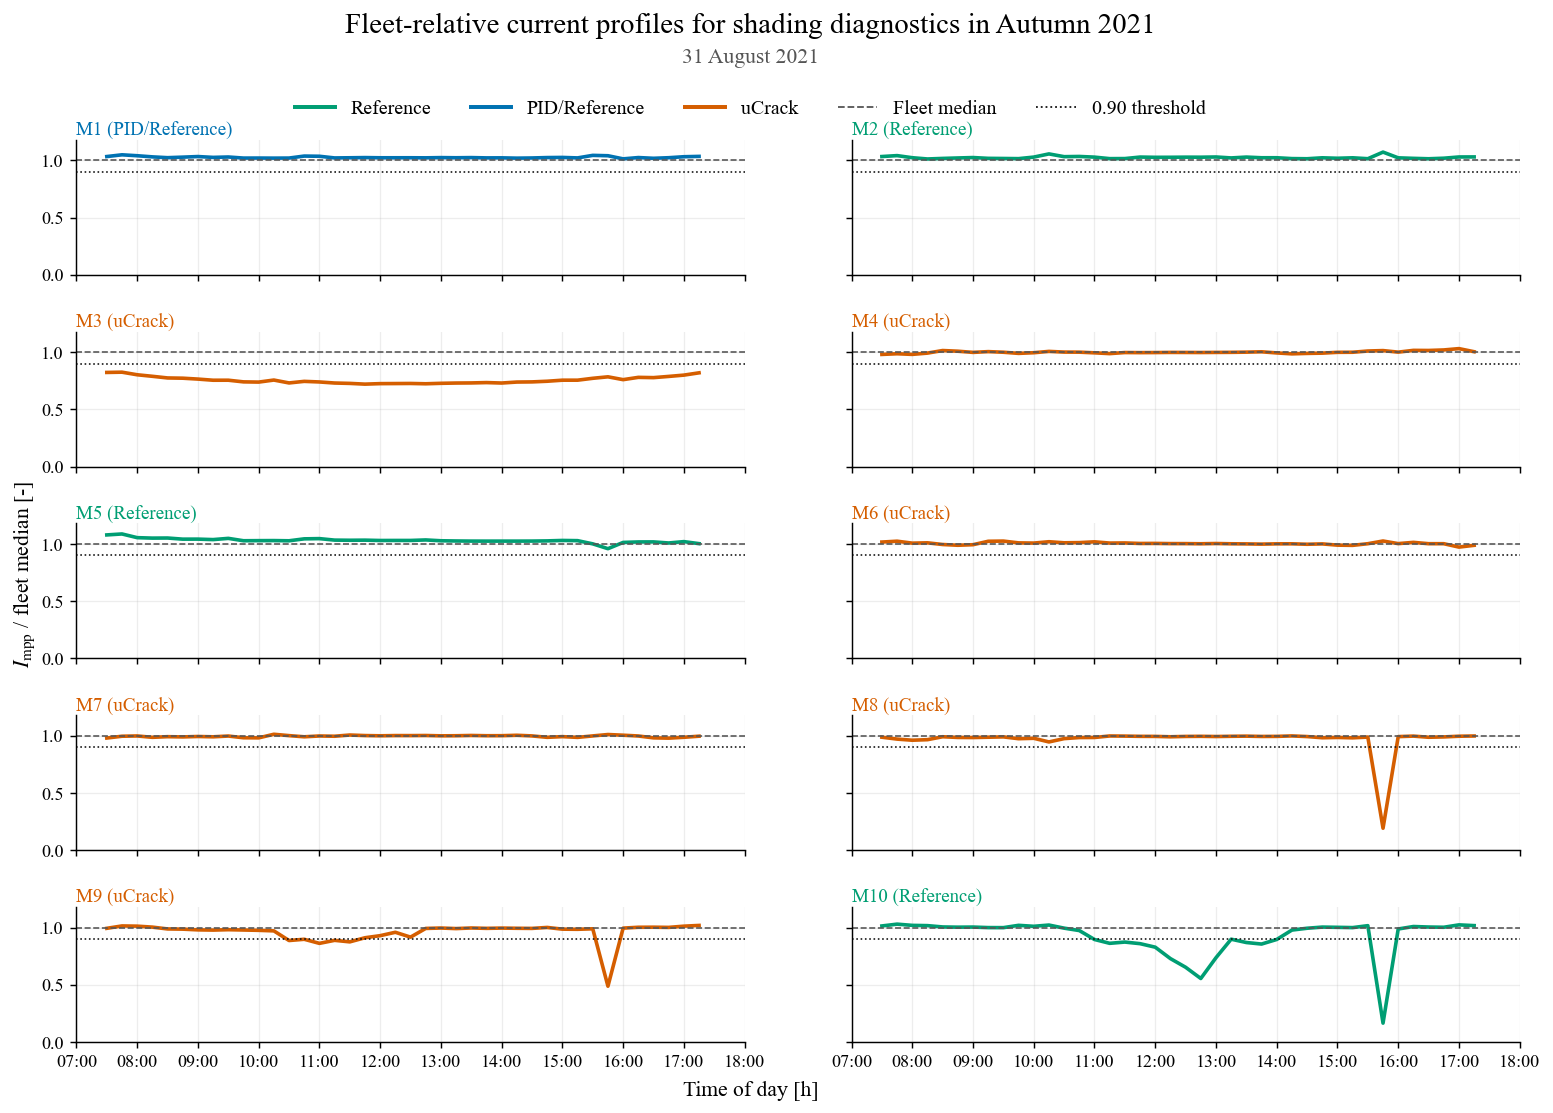

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\shading_fleet_relative_current_profiles_winter_2021.png


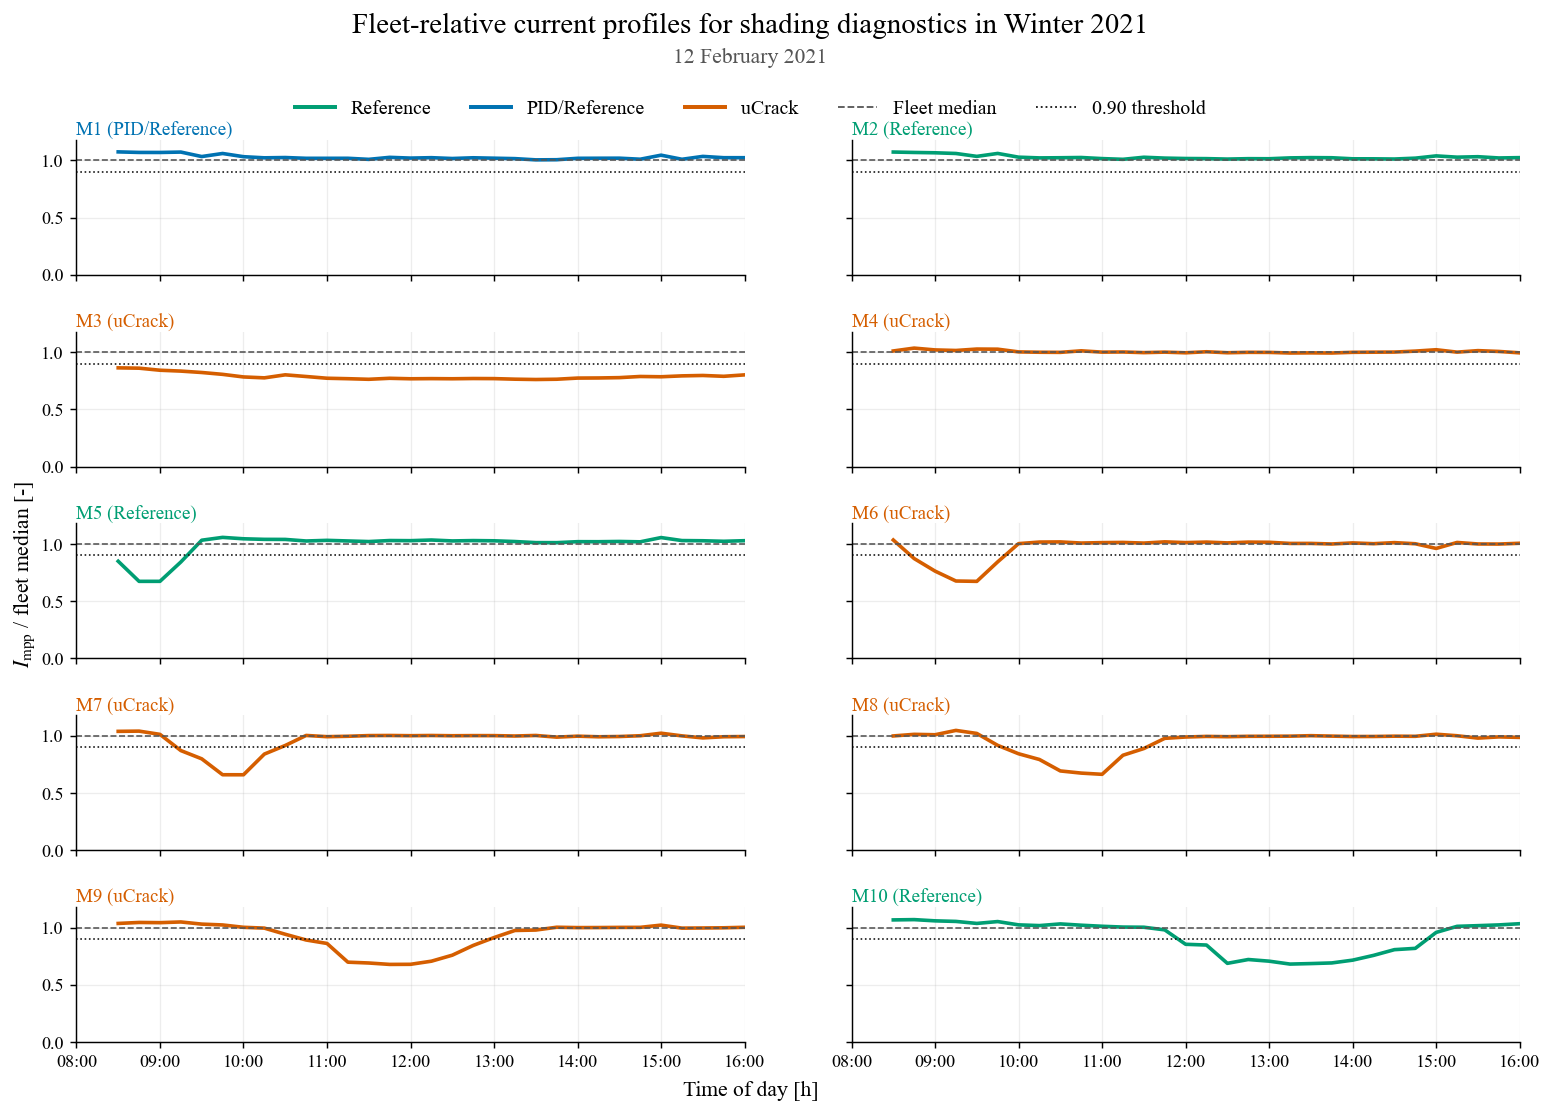

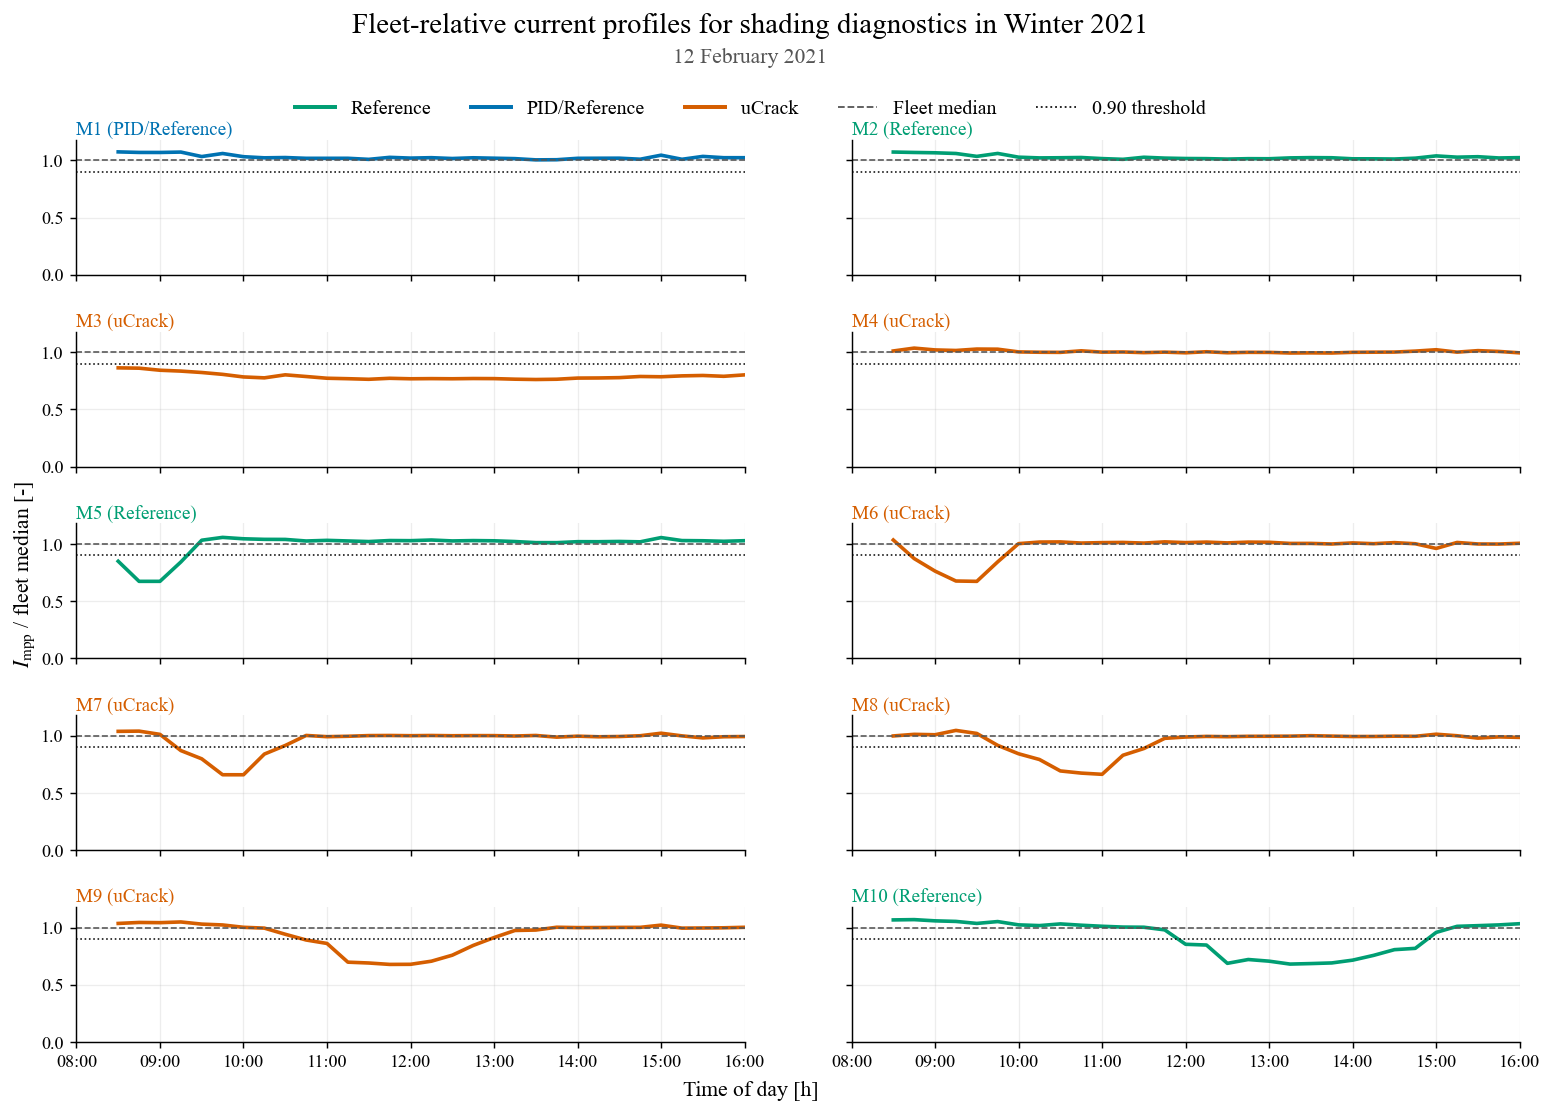

In [17]:
plot_fleet_relative_current_profiles(
    binned_df=binned_shading,
    day=CANDIDATE_DAYS["autumn_2021"],
    label="Autumn 2021",
    save=True,
)

plot_fleet_relative_current_profiles(
    binned_df=binned_shading,
    day=CANDIDATE_DAYS["winter_2021"],
    label="Winter 2021",
    save=True,
)

## 8. Prepare sunny-day SDM input

The single-diode model and fault classification are applied to the sunny-day dataset. The data are reduced to one row per module and 15-minute bin before SDM simulation.

In [19]:
try:
    import pvlib
    from pvlib import pvsystem
    from pvlib.ivtools import sdm as pvlib_sdm

    print("pvlib version:", pvlib.__version__)

except ModuleNotFoundError as exc:
    raise ImportError(
        "pvlib is required for this notebook. Install it with: pip install pvlib"
    ) from exc

pvlib version: 0.15.0


In [21]:
REQUIRED_SUNNY_COLUMNS = [
    "Module_ID",
    "Type",
    "Datetime_Bin_Local",
    "Date",
    "Year",
    "Month",
    "G_POA",
    "T_module",
    "P_MPP",
    "V_MPP",
    "I_MPP",
    "V_OC",
    "I_SC",
    "P_STC",
    "I_MPP_STC",
    "V_MPP_STC",
    "I_SC_STC",
    "V_OC_STC",
    "gamma_Pmp",
    "alpha_Isc",
    "beta_Voc",
    "metric_valid",
    "fleet_relative_valid",
    "sunny_sensitivity_day",
    "is_daylight_analysis_bin",
]

missing_cols = [col for col in REQUIRED_SUNNY_COLUMNS if col not in sunny.columns]

if missing_cols:
    raise KeyError(f"Missing required sunny columns: {missing_cols}")

sunny_model = sunny.copy()

sunny_model["metric_valid_bool"] = to_bool_series(sunny_model["metric_valid"])
sunny_model["fleet_relative_valid_bool"] = to_bool_series(sunny_model["fleet_relative_valid"])
sunny_model["sunny_sensitivity_day_bool"] = to_bool_series(sunny_model["sunny_sensitivity_day"])

numeric_cols = [
    "G_POA",
    "T_module",
    "P_MPP",
    "V_MPP",
    "I_MPP",
    "V_OC",
    "I_SC",
    "P_STC",
    "I_MPP_STC",
    "V_MPP_STC",
    "I_SC_STC",
    "V_OC_STC",
    "gamma_Pmp",
    "alpha_Isc",
    "beta_Voc",
]

for col in numeric_cols:
    sunny_model[col] = pd.to_numeric(sunny_model[col], errors="coerce")

In [22]:
sunny_model = (
    sunny_model
    .loc[sunny_model["is_daylight_analysis_bin"] == True]
    .loc[sunny_model["sunny_sensitivity_day_bool"] == True]
    .loc[sunny_model["metric_valid_bool"] == True]
    .loc[sunny_model["fleet_relative_valid_bool"] == True]
    .loc[sunny_model["G_POA"] >= G_MIN_SDM]
    .dropna(
        subset=[
            "Module_ID",
            "Datetime_Bin_Local",
            "Date",
            "G_POA",
            "T_module",
            "P_MPP",
            "V_MPP",
            "I_MPP",
        ]
    )
    .copy()
)

median_cols = [
    "G_POA",
    "T_module",
    "P_MPP",
    "V_MPP",
    "I_MPP",
    "V_OC",
    "I_SC",
]

optional_median_cols = [
    "PR_raw",
    "P_MPP_25C",
    "PR_25C",
    "FF_measured",
    "I_MPP_over_I_SC",
    "V_MPP_over_V_OC",
]

median_cols += [col for col in optional_median_cols if col in sunny_model.columns]

first_cols = [
    "P_STC",
    "I_MPP_STC",
    "V_MPP_STC",
    "I_SC_STC",
    "V_OC_STC",
    "gamma_Pmp",
    "alpha_Isc",
    "beta_Voc",
]

agg_kwargs = {col: (col, "median") for col in median_cols}
agg_kwargs.update({col: (col, "first") for col in first_cols})
agg_kwargs["n_raw_measurements_in_bin"] = ("P_MPP", "size")

sdm_input = (
    sunny_model
    .groupby(["Module_ID", "Type", "Datetime_Bin_Local", "Date"], as_index=False)
    .agg(**agg_kwargs)
    .sort_values(["Module_ID", "Datetime_Bin_Local"])
    .reset_index(drop=True)
)

sdm_input["Year"] = sdm_input["Datetime_Bin_Local"].dt.year
sdm_input["Month"] = sdm_input["Datetime_Bin_Local"].dt.month
sdm_input["Time_h"] = (
    sdm_input["Datetime_Bin_Local"].dt.hour
    + sdm_input["Datetime_Bin_Local"].dt.minute / 60
    + sdm_input["Datetime_Bin_Local"].dt.second / 3600
)

print("SDM input:", sdm_input.shape)
display(sdm_input.head())

SDM input: (149406, 29)


,Module_ID,Type,Datetime_Bin_Local,Date,G_POA,T_module,P_MPP,V_MPP,I_MPP,V_OC,I_SC,PR_raw,P_MPP_25C,PR_25C,FF_measured,I_MPP_over_I_SC,V_MPP_over_V_OC,P_STC,I_MPP_STC,V_MPP_STC,I_SC_STC,V_OC_STC,gamma_Pmp,alpha_Isc,beta_Voc,n_raw_measurements_in_bin,Year,Month,Time_h
0,1,PID/Reference,2017-01-02 10:15:00+01:00,2017-01-02,228.473284,2.844949,34.133574,19.730978,1.756157,23.279310,1.844527,0.995898,31.291964,0.912971,0.795433,0.939226,0.846919,150.0,8.22,18.79,8.61,22.21,-0.0041,0.0005,-0.0031,4,2017,1,10.25
1,1,PID/Reference,2017-01-02 10:30:00+01:00,2017-01-02,295.329329,5.083578,44.971913,19.437513,2.242659,23.356810,2.418717,1.015181,41.576857,0.938542,0.794599,0.952431,0.833102,150.0,8.22,18.79,8.61,22.21,-0.0041,0.0005,-0.0031,5,2017,1,10.50
2,1,PID/Reference,2017-01-02 10:45:00+01:00,2017-01-02,368.031554,7.164015,56.995456,20.031820,2.855681,23.409248,3.059540,1.031949,53.111646,0.962064,0.794357,0.928394,0.855730,150.0,8.22,18.79,8.61,22.21,-0.0041,0.0005,-0.0031,6,2017,1,10.75
3,1,PID/Reference,2017-01-02 11:00:00+01:00,2017-01-02,442.888780,10.589406,68.893313,19.435412,3.544649,23.421773,3.737039,1.036146,65.051866,0.979186,0.787113,0.946061,0.830712,150.0,8.22,18.79,8.61,22.21,-0.0041,0.0005,-0.0031,6,2017,1,11.00
4,1,PID/Reference,2017-01-02 11:15:00+01:00,2017-01-02,453.871878,14.034346,69.901529,19.433894,3.611791,23.124820,3.862537,1.028423,67.105067,0.985426,0.785889,0.937170,0.839498,150.0,8.22,18.79,8.61,22.21,-0.0041,0.0005,-0.0031,5,2017,1,11.25


## 9. Fit De Soto single-diode model parameters

A De Soto single-diode model is fitted using module reference parameters. The same fitted parameter structure is then used to simulate expected \(P_\mathrm{mpp}\), \(I_\mathrm{mpp}\), and \(V_\mathrm{mpp}\) under measured \(G_\mathrm{POA}\) and module temperature.

In [23]:
module_ref = (
    sdm_input[
        [
            "Module_ID",
            "Type",
            "P_STC",
            "I_MPP_STC",
            "V_MPP_STC",
            "I_SC_STC",
            "V_OC_STC",
            "gamma_Pmp",
            "alpha_Isc",
            "beta_Voc",
        ]
    ]
    .drop_duplicates()
    .sort_values("Module_ID")
    .reset_index(drop=True)
)

duplicate_count = module_ref.groupby("Module_ID").size()

if (duplicate_count > 1).any():
    display(module_ref)
    raise ValueError("More than one reference-parameter row found for at least one module.")

module_ref["cells_in_series"] = CELLS_IN_SERIES

module_ref["alpha_sc_A_per_K"] = module_ref["alpha_Isc"] * module_ref["I_SC_STC"]
module_ref["beta_voc_V_per_K"] = module_ref["beta_Voc"] * module_ref["V_OC_STC"]

display(module_ref)

,Module_ID,Type,P_STC,I_MPP_STC,V_MPP_STC,I_SC_STC,V_OC_STC,gamma_Pmp,alpha_Isc,beta_Voc,cells_in_series,alpha_sc_A_per_K,beta_voc_V_per_K
0,1,PID/Reference,150.0,8.22,18.79,8.61,22.21,-0.0041,0.0005,-0.0031,36,0.004305,-0.068851
1,2,Reference,150.0,8.22,18.79,8.61,22.21,-0.0041,0.0005,-0.0031,36,0.004305,-0.068851
2,3,uCrack,150.0,8.22,18.79,8.61,22.21,-0.0041,0.0005,-0.0031,36,0.004305,-0.068851
3,4,uCrack,150.0,8.22,18.79,8.61,22.21,-0.0041,0.0005,-0.0031,36,0.004305,-0.068851
4,5,Reference,150.0,8.22,18.79,8.61,22.21,-0.0041,0.0005,-0.0031,36,0.004305,-0.068851
5,6,uCrack,150.0,8.22,18.79,8.61,22.21,-0.0041,0.0005,-0.0031,36,0.004305,-0.068851
6,7,uCrack,150.0,8.22,18.79,8.61,22.21,-0.0041,0.0005,-0.0031,36,0.004305,-0.068851
7,8,uCrack,150.0,8.22,18.79,8.61,22.21,-0.0041,0.0005,-0.0031,36,0.004305,-0.068851
8,9,uCrack,150.0,8.22,18.79,8.61,22.21,-0.0041,0.0005,-0.0031,36,0.004305,-0.068851
9,10,Reference,150.0,8.22,18.79,8.61,22.21,-0.0041,0.0005,-0.0031,36,0.004305,-0.068851


In [24]:
DESOTO_FIT_ATTEMPTS = [
    {
        "attempt_name": "default",
        "root_kwargs": {},
    },
    {
        "attempt_name": "hybr_maxfev_5000",
        "root_kwargs": {
            "method": "hybr",
            "options": {"maxfev": 5000},
        },
    },
    {
        "attempt_name": "levenberg_marquardt",
        "root_kwargs": {
            "method": "lm",
            "options": {"maxiter": 5000},
        },
    },
]


def run_fit_desoto_once(row, root_kwargs):
    fit_output = pvlib_sdm.fit_desoto(
        v_mp=float(row["V_MPP_STC"]),
        i_mp=float(row["I_MPP_STC"]),
        v_oc=float(row["V_OC_STC"]),
        i_sc=float(row["I_SC_STC"]),
        alpha_sc=float(row["alpha_sc_A_per_K"]),
        beta_voc=float(row["beta_voc_V_per_K"]),
        cells_in_series=int(row["cells_in_series"]),
        EgRef=EG_REF,
        dEgdT=DEG_DT,
        temp_ref=TEMP_REF,
        irrad_ref=IRRAD_REF,
        root_kwargs=root_kwargs,
    )

    if isinstance(fit_output, tuple):
        params, opt_result = fit_output
    else:
        params = fit_output
        opt_result = None

    fit_success = True
    fit_message = ""

    if opt_result is not None:
        fit_success = bool(getattr(opt_result, "success", True))
        fit_message = str(getattr(opt_result, "message", ""))

    return params, fit_success, fit_message


def fit_desoto_for_module(row):
    module_id = int(row["Module_ID"])
    last_error = ""

    for attempt in DESOTO_FIT_ATTEMPTS:
        try:
            params, fit_success, fit_message = run_fit_desoto_once(
                row=row,
                root_kwargs=attempt["root_kwargs"],
            )

            required_keys = ["I_L_ref", "I_o_ref", "R_s", "R_sh_ref", "a_ref"]

            params_valid = all(
                key in params and np.isfinite(params[key])
                for key in required_keys
            )

            if fit_success and params_valid:
                result = {
                    "Module_ID": module_id,
                    "Type": row["Type"],
                    "fit_success": True,
                    "fit_attempt_used": attempt["attempt_name"],
                    "fit_message": fit_message,
                    "cells_in_series": int(row["cells_in_series"]),
                    "alpha_sc_A_per_K": float(row["alpha_sc_A_per_K"]),
                    "beta_voc_V_per_K": float(row["beta_voc_V_per_K"]),
                    "EgRef": EG_REF,
                    "dEgdT": DEG_DT,
                    "irrad_ref": IRRAD_REF,
                    "temp_ref": TEMP_REF,
                }

                for key, value in params.items():
                    result[key] = value

                return result

            last_error = f"{attempt['attempt_name']} did not converge cleanly."

        except Exception as exc:
            last_error = f"{attempt['attempt_name']} failed: {exc}"

    return {
        "Module_ID": module_id,
        "Type": row["Type"],
        "fit_success": False,
        "fit_attempt_used": "all_failed",
        "fit_message": last_error,
    }

In [25]:
sdm_params = pd.DataFrame([
    fit_desoto_for_module(row)
    for _, row in module_ref.iterrows()
])

display(sdm_params)

if not sdm_params["fit_success"].all():
    raise RuntimeError("At least one module failed De Soto SDM fitting.")

sdm_params.to_csv(
    FINAL_TABLE_DIR / "shading_desoto_sdm_parameters_by_module.csv",
    index=False,
)

,Module_ID,Type,fit_success,fit_attempt_used,fit_message,cells_in_series,alpha_sc_A_per_K,beta_voc_V_per_K,EgRef,dEgdT,irrad_ref,temp_ref,I_L_ref,I_o_ref,R_s,R_sh_ref,a_ref,alpha_sc
0,1,PID/Reference,True,levenberg_marquardt,Both actual and predicted relative reductions ...,36,0.004305,-0.068851,1.121,-0.000268,1000.0,25.0,8.610097,4.530621e-11,0.094157,8.087651e+12,0.855201,0.004305
1,2,Reference,True,levenberg_marquardt,Both actual and predicted relative reductions ...,36,0.004305,-0.068851,1.121,-0.000268,1000.0,25.0,8.610097,4.530621e-11,0.094157,8.087651e+12,0.855201,0.004305
2,3,uCrack,True,levenberg_marquardt,Both actual and predicted relative reductions ...,36,0.004305,-0.068851,1.121,-0.000268,1000.0,25.0,8.610097,4.530621e-11,0.094157,8.087651e+12,0.855201,0.004305
3,4,uCrack,True,levenberg_marquardt,Both actual and predicted relative reductions ...,36,0.004305,-0.068851,1.121,-0.000268,1000.0,25.0,8.610097,4.530621e-11,0.094157,8.087651e+12,0.855201,0.004305
4,5,Reference,True,levenberg_marquardt,Both actual and predicted relative reductions ...,36,0.004305,-0.068851,1.121,-0.000268,1000.0,25.0,8.610097,4.530621e-11,0.094157,8.087651e+12,0.855201,0.004305
5,6,uCrack,True,levenberg_marquardt,Both actual and predicted relative reductions ...,36,0.004305,-0.068851,1.121,-0.000268,1000.0,25.0,8.610097,4.530621e-11,0.094157,8.087651e+12,0.855201,0.004305
6,7,uCrack,True,levenberg_marquardt,Both actual and predicted relative reductions ...,36,0.004305,-0.068851,1.121,-0.000268,1000.0,25.0,8.610097,4.530621e-11,0.094157,8.087651e+12,0.855201,0.004305
7,8,uCrack,True,levenberg_marquardt,Both actual and predicted relative reductions ...,36,0.004305,-0.068851,1.121,-0.000268,1000.0,25.0,8.610097,4.530621e-11,0.094157,8.087651e+12,0.855201,0.004305
8,9,uCrack,True,levenberg_marquardt,Both actual and predicted relative reductions ...,36,0.004305,-0.068851,1.121,-0.000268,1000.0,25.0,8.610097,4.530621e-11,0.094157,8.087651e+12,0.855201,0.004305
9,10,Reference,True,levenberg_marquardt,Both actual and predicted relative reductions ...,36,0.004305,-0.068851,1.121,-0.000268,1000.0,25.0,8.610097,4.530621e-11,0.094157,8.087651e+12,0.855201,0.004305


## 10. Simulate expected SDM outputs

The fitted single-diode model is evaluated at measured irradiance and module temperature for each module-bin.

In [26]:
def simulate_sdm_condition(effective_irradiance, temp_cell, params_row):
    photocurrent, saturation_current, resistance_series, resistance_shunt, nNsVth = (
        pvsystem.calcparams_desoto(
            effective_irradiance=effective_irradiance,
            temp_cell=temp_cell,
            alpha_sc=float(params_row["alpha_sc_A_per_K"]),
            a_ref=float(params_row["a_ref"]),
            I_L_ref=float(params_row["I_L_ref"]),
            I_o_ref=float(params_row["I_o_ref"]),
            R_sh_ref=float(params_row["R_sh_ref"]),
            R_s=float(params_row["R_s"]),
            EgRef=float(params_row["EgRef"]),
            dEgdT=float(params_row["dEgdT"]),
            irrad_ref=float(params_row["irrad_ref"]),
            temp_ref=float(params_row["temp_ref"]),
        )
    )

    return pvsystem.singlediode(
        photocurrent=photocurrent,
        saturation_current=saturation_current,
        resistance_series=resistance_series,
        resistance_shunt=resistance_shunt,
        nNsVth=nNsVth,
        method="lambertw",
    )


def simulate_module_dataframe(module_df, params_row):
    module_df = module_df.copy()

    try:
        sd_out = simulate_sdm_condition(
            effective_irradiance=module_df["G_POA"].astype(float).to_numpy(),
            temp_cell=module_df["T_module"].astype(float).to_numpy(),
            params_row=params_row,
        )

        module_df["sdm_success"] = True
        module_df["I_SC_sd"] = np.asarray(sd_out["i_sc"], dtype=float)
        module_df["V_OC_sd"] = np.asarray(sd_out["v_oc"], dtype=float)
        module_df["I_MPP_sd"] = np.asarray(sd_out["i_mp"], dtype=float)
        module_df["V_MPP_sd"] = np.asarray(sd_out["v_mp"], dtype=float)
        module_df["P_MPP_sd"] = np.asarray(sd_out["p_mp"], dtype=float)

    except Exception as exc:
        module_df["sdm_success"] = False
        module_df["sdm_error"] = str(exc)
        module_df["I_SC_sd"] = np.nan
        module_df["V_OC_sd"] = np.nan
        module_df["I_MPP_sd"] = np.nan
        module_df["V_MPP_sd"] = np.nan
        module_df["P_MPP_sd"] = np.nan

    return module_df

In [27]:
sim_tables = []

for module_id, module_df in sdm_input.groupby("Module_ID"):
    params_row = sdm_params.loc[sdm_params["Module_ID"] == module_id].iloc[0]

    sim_tables.append(
        simulate_module_dataframe(
            module_df=module_df,
            params_row=params_row,
        )
    )

df_sim = (
    pd.concat(sim_tables, ignore_index=True)
    .sort_values(["Module_ID", "Datetime_Bin_Local"])
    .reset_index(drop=True)
)

df_sim["P_MPP_ratio_meas_sd"] = df_sim["P_MPP"] / df_sim["P_MPP_sd"].replace(0, np.nan)
df_sim["I_MPP_ratio_meas_sd"] = df_sim["I_MPP"] / df_sim["I_MPP_sd"].replace(0, np.nan)
df_sim["V_MPP_ratio_meas_sd"] = df_sim["V_MPP"] / df_sim["V_MPP_sd"].replace(0, np.nan)

print("Simulated dataset:", df_sim.shape)
display(df_sim.head())

Simulated dataset: (149406, 38)


,Module_ID,Type,Datetime_Bin_Local,Date,G_POA,T_module,P_MPP,V_MPP,I_MPP,V_OC,I_SC,PR_raw,P_MPP_25C,PR_25C,FF_measured,I_MPP_over_I_SC,V_MPP_over_V_OC,P_STC,I_MPP_STC,V_MPP_STC,I_SC_STC,V_OC_STC,gamma_Pmp,alpha_Isc,beta_Voc,n_raw_measurements_in_bin,Year,Month,Time_h,sdm_success,I_SC_sd,V_OC_sd,I_MPP_sd,V_MPP_sd,P_MPP_sd,P_MPP_ratio_meas_sd,I_MPP_ratio_meas_sd,V_MPP_ratio_meas_sd
0,1,PID/Reference,2017-01-02 10:15:00+01:00,2017-01-02,228.473284,2.844949,34.133574,19.730978,1.756157,23.279310,1.844527,0.995898,31.291964,0.912971,0.795433,0.939226,0.846919,150.0,8.22,18.79,8.61,22.21,-0.0041,0.0005,-0.0031,4,2017,1,10.25,True,1.945386,22.554688,1.869987,19.810155,37.044743,0.921415,0.939128,0.996003
1,1,PID/Reference,2017-01-02 10:30:00+01:00,2017-01-02,295.329329,5.083578,44.971913,19.437513,2.242659,23.356810,2.418717,1.015181,41.576857,0.938542,0.794599,0.952431,0.833102,150.0,8.22,18.79,8.61,22.21,-0.0041,0.0005,-0.0031,5,2017,1,10.50,True,2.517493,22.601562,2.418809,19.789222,47.866357,0.939531,0.927175,0.982227
2,1,PID/Reference,2017-01-02 10:45:00+01:00,2017-01-02,368.031554,7.164015,56.995456,20.031820,2.855681,23.409248,3.059540,1.031949,53.111646,0.962064,0.794357,0.928394,0.855730,150.0,8.22,18.79,8.61,22.21,-0.0041,0.0005,-0.0031,6,2017,1,10.75,True,3.140528,22.617188,3.015959,19.750725,59.567387,0.956823,0.946857,1.014232
3,1,PID/Reference,2017-01-02 11:00:00+01:00,2017-01-02,442.888780,10.589406,68.893313,19.435412,3.544649,23.421773,3.737039,1.036146,65.051866,0.979186,0.787113,0.946061,0.830712,150.0,8.22,18.79,8.61,22.21,-0.0041,0.0005,-0.0031,6,2017,1,11.00,True,3.785840,22.546875,3.632226,19.586076,71.141063,0.968404,0.975889,0.992308
4,1,PID/Reference,2017-01-02 11:15:00+01:00,2017-01-02,453.871878,14.034346,69.901529,19.433894,3.611791,23.124820,3.862537,1.028423,67.105067,0.985426,0.785889,0.937170,0.839498,150.0,8.22,18.79,8.61,22.21,-0.0041,0.0005,-0.0031,5,2017,1,11.25,True,3.886455,22.328125,3.724887,19.341880,72.046313,0.970230,0.969638,1.004757


In [28]:
sdm_ratio_summary = (
    df_sim
    .groupby(["Module_ID", "Type"], as_index=False)
    .agg(
        n_bins=("P_MPP", "size"),
        median_P_meas_over_SDM=("P_MPP_ratio_meas_sd", "median"),
        median_I_meas_over_SDM=("I_MPP_ratio_meas_sd", "median"),
        median_V_meas_over_SDM=("V_MPP_ratio_meas_sd", "median"),
        p05_P_meas_over_SDM=("P_MPP_ratio_meas_sd", lambda x: x.quantile(0.05)),
        p95_P_meas_over_SDM=("P_MPP_ratio_meas_sd", lambda x: x.quantile(0.95)),
    )
)

display(sdm_ratio_summary)

sdm_ratio_summary.to_csv(
    FINAL_TABLE_DIR / "shading_sdm_measured_to_model_ratio_summary.csv",
    index=False,
)

,Module_ID,Type,n_bins,median_P_meas_over_SDM,median_I_meas_over_SDM,median_V_meas_over_SDM,p05_P_meas_over_SDM,p95_P_meas_over_SDM
0,1,PID/Reference,15029,0.950435,0.970784,0.985060,0.811540,1.011168
1,2,Reference,15030,0.946944,0.969597,0.983144,0.808427,1.009812
2,3,uCrack,14237,0.656796,0.721928,0.911166,0.574356,0.724645
3,4,uCrack,15033,0.908010,0.949879,0.961625,0.771206,0.973268
4,5,Reference,15026,0.960511,0.979332,0.985400,0.815749,1.017077
5,6,uCrack,15035,0.923768,0.962061,0.965497,0.785570,0.981050
6,7,uCrack,15011,0.907709,0.954791,0.954542,0.751664,0.964250
7,8,uCrack,15023,0.907534,0.951396,0.958909,0.742198,0.965987
8,9,uCrack,14996,0.912278,0.959323,0.958518,0.736079,0.980537
9,10,Reference,14986,0.942570,0.959518,0.988081,0.722657,1.005386


## 11. Measured versus simulated outputs for Modules 2 and 10

This figure compares measured and single-diode simulated \(P_\mathrm{mpp}\), \(I_\mathrm{mpp}\), and \(V_\mathrm{mpp}\) for Modules 2 and 10 on the selected autumn diagnostic day.

In [29]:
def plot_measured_vs_sdm_m2_m10(
    df_sim,
    day,
    save=True,
):
    day = pd.Timestamp(day).normalize()

    day_df = (
        df_sim
        .loc[
            (df_sim["Date"] == day)
            & (df_sim["Module_ID"].isin([2, 10]))
        ]
        .copy()
    )

    if day_df.empty:
        print(f"No SDM data found for {day.date()}.")
        return None

    day_df = (
        day_df
        .groupby(["Module_ID", "Datetime_Bin_Local", "Time_h"], as_index=False)
        .agg(
            P_MPP=("P_MPP", "median"),
            P_MPP_sd=("P_MPP_sd", "median"),
            I_MPP=("I_MPP", "median"),
            I_MPP_sd=("I_MPP_sd", "median"),
            V_MPP=("V_MPP", "median"),
            V_MPP_sd=("V_MPP_sd", "median"),
        )
        .sort_values(["Module_ID", "Time_h"])
    )

    metric_specs = [
        ("P_MPP", "P_MPP_sd", r"$P_\mathrm{mpp}$ [W]"),
        ("I_MPP", "I_MPP_sd", r"$I_\mathrm{mpp}$ [A]"),
        ("V_MPP", "V_MPP_sd", r"$V_\mathrm{mpp}$ [V]"),
    ]

    colors = {
        2: "#0072B2",
        10: "#D55E00",
    }

    fig, axes = plt.subplots(
        nrows=3,
        ncols=1,
        figsize=(11.4, 7.3),
        sharex=True,
    )

    for ax, (meas_col, sd_col, ylabel) in zip(axes, metric_specs):
        for module_id in [2, 10]:
            module_df = (
                day_df
                .loc[day_df["Module_ID"] == module_id]
                .sort_values("Time_h")
                .copy()
            )

            ax.scatter(
                module_df["Time_h"],
                module_df[meas_col],
                color=colors[module_id],
                s=26,
                alpha=0.85,
                label=f"M{module_id} measured" if ax is axes[0] else None,
                zorder=3,
            )

            ax.scatter(
                module_df["Time_h"],
                module_df[sd_col],
                facecolors="none",
                edgecolors=colors[module_id],
                s=34,
                linewidths=1.2,
                alpha=0.95,
                label=f"M{module_id} SDM" if ax is axes[0] else None,
                zorder=2,
            )

        ax.set_ylabel(ylabel, fontsize=AXIS_LABEL_SIZE)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    xmin = np.floor(day_df["Time_h"].min())
    xmax = np.ceil(day_df["Time_h"].max())
    ticks = np.arange(xmin, xmax + 0.1, 1)

    for ax in axes:
        ax.set_xlim(xmin, xmax)
        ax.set_xticks(ticks)
        ax.set_xticklabels([f"{int(t):02d}:00" for t in ticks])

    axes[-1].set_xlabel("Time of day [h]", fontsize=AXIS_LABEL_SIZE)

    fig.suptitle(
        f"Measured and single-diode simulated outputs for M2 and M10 on {day.strftime('%d %B %Y').lstrip('0')}",
        fontsize=TITLE_SIZE,
        y=0.985,
    )

    axes[0].legend(
        frameon=True,
        ncol=2,
        loc="best",
        fontsize=LEGEND_SIZE,
    )

    fig.subplots_adjust(
        left=0.09,
        right=0.985,
        top=0.925,
        bottom=0.08,
        hspace=0.22,
    )

    if save:
        save_fig(f"shading_measured_vs_sdm_m2_m10_{day.strftime('%Y_%m_%d')}.png", fig)

    plt.show()
    return fig

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\shading_measured_vs_sdm_m2_m10_2021_08_31.png


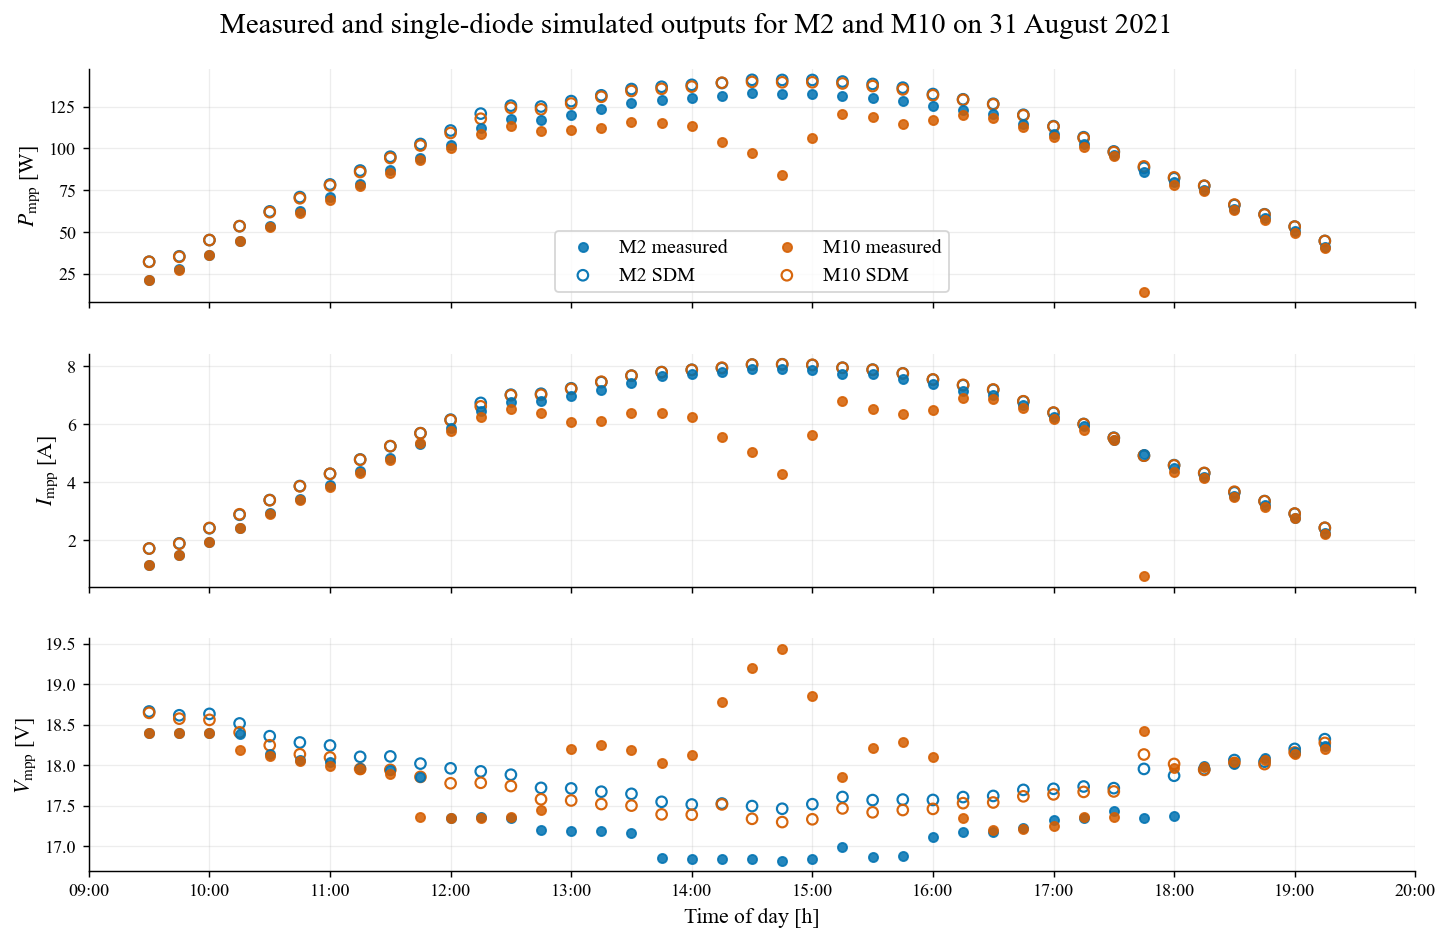

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\shading_measured_vs_sdm_m2_m10_2021_02_12.png


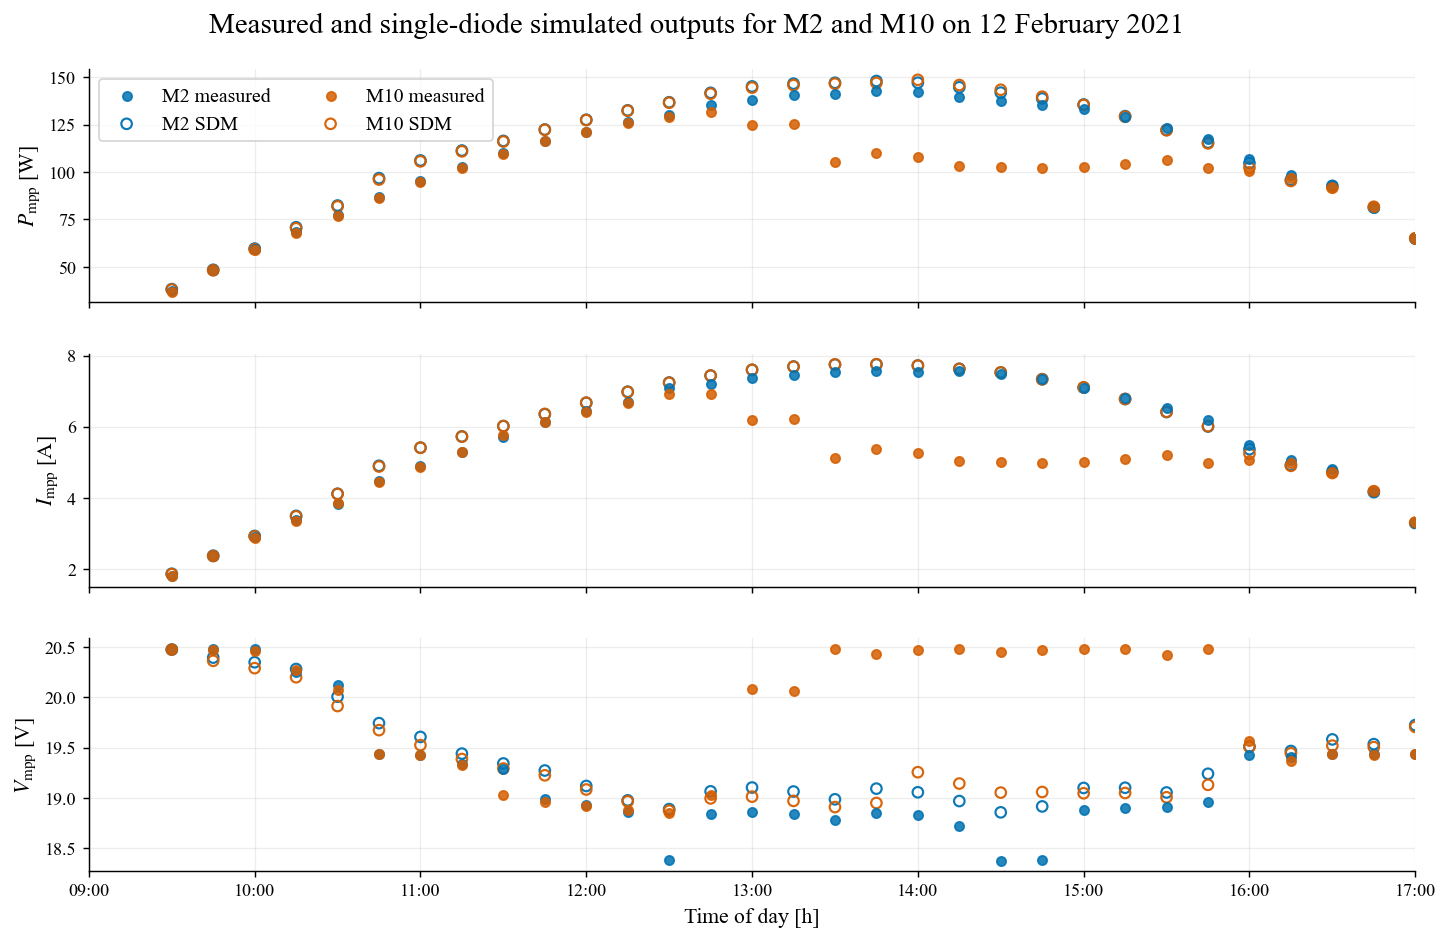

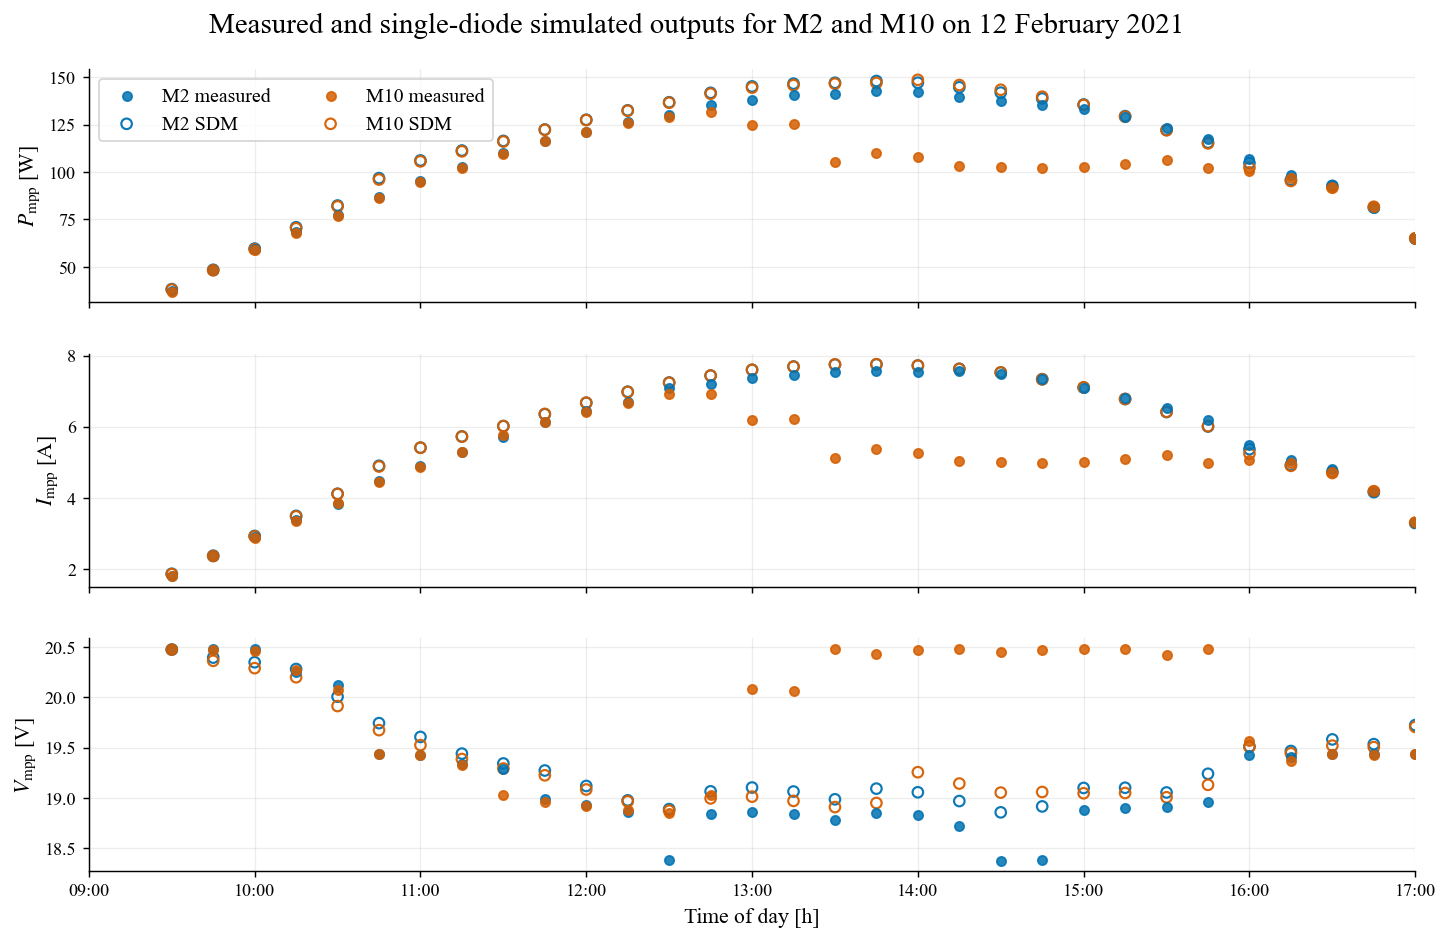

In [31]:
plot_measured_vs_sdm_m2_m10(
    df_sim=df_sim,
    day=CANDIDATE_DAYS["autumn_2021"],
    save=True,
)

plot_measured_vs_sdm_m2_m10(
    df_sim=df_sim,
    day=CANDIDATE_DAYS["winter_2021"],
    save=True,
)

## 12. Fault classification

Each sunny-day module-bin is classified using voltage and current thresholds around the SDM prediction. F0 represents operation close to the simulated response. F2-F5 are treated as fault-candidate or non-normal operating periods.

F1 is not assigned separately because this workflow is already restricted to the sunny-day dataset.

In [32]:
def add_daily_sigma_table(df_in, sigma_source="simulated"):
    """
    Compute module-day sigma values used in the voltage/current thresholds.
    """
    if sigma_source == "simulated":
        v_col = "V_MPP_sd"
        i_col = "I_MPP_sd"
    elif sigma_source == "measured":
        v_col = "V_MPP"
        i_col = "I_MPP"
    elif sigma_source == "residual":
        df_in = df_in.copy()
        df_in["V_MPP_residual"] = df_in["V_MPP"] - df_in["V_MPP_sd"]
        df_in["I_MPP_residual"] = df_in["I_MPP"] - df_in["I_MPP_sd"]
        v_col = "V_MPP_residual"
        i_col = "I_MPP_residual"
    else:
        raise ValueError("sigma_source must be simulated, measured, or residual.")

    daily_sigma = (
        df_in
        .groupby(["Module_ID", "Date"], as_index=False)
        .agg(
            n_bins_day=("Datetime_Bin_Local", "nunique"),
            sigma_V=(v_col, "std"),
            sigma_I=(i_col, "std"),
        )
    )

    daily_sigma["daily_threshold_valid"] = (
        (daily_sigma["n_bins_day"] >= MIN_BINS_FOR_DAILY_SIGMA)
        & daily_sigma["sigma_V"].notna()
        & daily_sigma["sigma_I"].notna()
    )

    return daily_sigma


daily_sigma = add_daily_sigma_table(df_sim, sigma_source=SIGMA_SOURCE)

display(daily_sigma.head())

,Module_ID,Date,n_bins_day,sigma_V,sigma_I,daily_threshold_valid
0,1,2017-01-02,21,0.167946,1.216418,True
1,1,2017-01-05,23,0.187761,1.315057,True
2,1,2017-01-06,23,0.343045,1.185698,True
3,1,2017-01-16,21,0.218663,0.983057,True
4,1,2017-01-20,22,0.221262,1.464154,True


In [33]:
def add_daily_sigma_table(df_in, sigma_source="simulated"):
    """
    Compute module-day sigma values used in the voltage/current thresholds.
    """
    if sigma_source == "simulated":
        v_col = "V_MPP_sd"
        i_col = "I_MPP_sd"
    elif sigma_source == "measured":
        v_col = "V_MPP"
        i_col = "I_MPP"
    elif sigma_source == "residual":
        df_in = df_in.copy()
        df_in["V_MPP_residual"] = df_in["V_MPP"] - df_in["V_MPP_sd"]
        df_in["I_MPP_residual"] = df_in["I_MPP"] - df_in["I_MPP_sd"]
        v_col = "V_MPP_residual"
        i_col = "I_MPP_residual"
    else:
        raise ValueError("sigma_source must be simulated, measured, or residual.")

    daily_sigma = (
        df_in
        .groupby(["Module_ID", "Date"], as_index=False)
        .agg(
            n_bins_day=("Datetime_Bin_Local", "nunique"),
            sigma_V=(v_col, "std"),
            sigma_I=(i_col, "std"),
        )
    )

    daily_sigma["daily_threshold_valid"] = (
        (daily_sigma["n_bins_day"] >= MIN_BINS_FOR_DAILY_SIGMA)
        & daily_sigma["sigma_V"].notna()
        & daily_sigma["sigma_I"].notna()
    )

    return daily_sigma


daily_sigma = add_daily_sigma_table(df_sim, sigma_source=SIGMA_SOURCE)

display(daily_sigma.head())

,Module_ID,Date,n_bins_day,sigma_V,sigma_I,daily_threshold_valid
0,1,2017-01-02,21,0.167946,1.216418,True
1,1,2017-01-05,23,0.187761,1.315057,True
2,1,2017-01-06,23,0.343045,1.185698,True
3,1,2017-01-16,21,0.218663,0.983057,True
4,1,2017-01-20,22,0.221262,1.464154,True


In [34]:
df_class = df_sim.merge(
    daily_sigma[
        [
            "Module_ID",
            "Date",
            "n_bins_day",
            "sigma_V",
            "sigma_I",
            "daily_threshold_valid",
        ]
    ],
    on=["Module_ID", "Date"],
    how="left",
    validate="many_to_one",
)

df_class["V_th_low"] = df_class["V_MPP_sd"] - 2.0 * df_class["sigma_V"]
df_class["V_th_high"] = df_class["V_MPP_sd"]
df_class["I_th_low"] = df_class["I_MPP_sd"] - 0.5 * df_class["sigma_I"]

In [35]:
def classify_faults(df_in):
    """
    Classify each sunny-day bin.

    F0: V_low <= V_MPP <= V_high and I_MPP >= I_low
    F2: V_MPP < V_low and I_MPP < I_low
    F3: V_MPP < V_low and I_MPP >= I_low
    F4: V_MPP >= V_low and I_MPP < I_low
    F5: V_MPP > V_high and I_MPP >= I_low
    """
    out = df_in.copy()

    out["fault_class"] = "UNCLASSIFIED"

    required = [
        "V_MPP",
        "I_MPP",
        "V_th_low",
        "V_th_high",
        "I_th_low",
        "sdm_success",
        "daily_threshold_valid",
    ]

    valid_base = out[required].notna().all(axis=1)
    valid_base = valid_base & (out["sdm_success"] == True)
    valid_base = valid_base & (out["daily_threshold_valid"] == True)

    out.loc[out["sdm_success"] != True, "fault_class"] = "SDM_FAILED"

    out.loc[
        (out["sdm_success"] == True)
        & (out["daily_threshold_valid"] != True),
        "fault_class",
    ] = "THRESHOLD_FAILED"

    v = out["V_MPP"]
    i = out["I_MPP"]

    v_low = out["V_th_low"]
    v_high = out["V_th_high"]
    i_low = out["I_th_low"]

    out.loc[
        valid_base & (v >= v_low) & (v <= v_high) & (i >= i_low),
        "fault_class",
    ] = "F0"

    out.loc[
        valid_base & (v < v_low) & (i < i_low),
        "fault_class",
    ] = "F2"

    out.loc[
        valid_base & (v < v_low) & (i >= i_low),
        "fault_class",
    ] = "F3"

    out.loc[
        valid_base & (v >= v_low) & (i < i_low),
        "fault_class",
    ] = "F4"

    out.loc[
        valid_base & (v > v_high) & (i >= i_low),
        "fault_class",
    ] = "F5"

    out["is_f0_intrinsic"] = out["fault_class"].eq("F0")
    out["is_fault_candidate"] = out["fault_class"].isin(["F2", "F3", "F4", "F5"])

    return out


df_classified = classify_faults(df_class)

display(df_classified["fault_class"].value_counts(dropna=False))

fault_class
F0    76527
F3    51042
F2    10353
F5     8519
F4     2965
Name: count, dtype: int64

## 13. Fault-class summaries and plots

The fault-class summaries show how much of each module's sunny-day operation is classified as F0 compared with fault-candidate operation.

In [36]:
overall_fault_counts = (
    df_classified["fault_class"]
    .value_counts()
    .reindex(CLASS_ORDER, fill_value=0)
    .rename_axis("fault_class")
    .reset_index(name="n_bins")
)

overall_fault_counts["pct_bins"] = (
    100 * overall_fault_counts["n_bins"] / overall_fault_counts["n_bins"].sum()
)

display(overall_fault_counts)

fault_summary_by_module = pd.crosstab(
    index=[
        df_classified["Module_ID"],
        df_classified["Type"],
    ],
    columns=df_classified["fault_class"],
)

fault_summary_by_module = fault_summary_by_module.reindex(
    columns=CLASS_ORDER,
    fill_value=0,
)

fault_summary_by_module["total_bins"] = fault_summary_by_module.sum(axis=1)

fault_summary_by_module["F0_fraction"] = (
    fault_summary_by_module["F0"] / fault_summary_by_module["total_bins"]
)

fault_summary_by_module["fault_candidate_fraction"] = (
    fault_summary_by_module[["F2", "F3", "F4", "F5"]].sum(axis=1)
    / fault_summary_by_module["total_bins"]
)

fault_summary_by_module = fault_summary_by_module.reset_index()

display(fault_summary_by_module)

,fault_class,n_bins,pct_bins
0,F0,76527,51.220835
1,F1,0,0.000000
2,F2,10353,6.929441
3,F3,51042,34.163287
4,F4,2965,1.984525
5,F5,8519,5.701913
6,SDM_FAILED,0,0.000000
7,THRESHOLD_FAILED,0,0.000000
8,UNCLASSIFIED,0,0.000000


fault_class,Module_ID,Type,F0,F1,F2,F3,F4,F5,SDM_FAILED,THRESHOLD_FAILED,UNCLASSIFIED,total_bins,F0_fraction,fault_candidate_fraction
0,1,PID/Reference,10901,0,14,1910,81,2123,0,0,0,15029,0.725331,0.274669
1,2,Reference,11143,0,11,1893,90,1893,0,0,0,15030,0.741384,0.258616
2,3,uCrack,2,0,10050,4168,17,0,0,0,0,14237,0.000140,0.999860
3,4,uCrack,6680,0,52,8145,123,33,0,0,0,15033,0.444356,0.555644
4,5,Reference,12484,0,18,787,143,1594,0,0,0,15026,0.830827,0.169173
5,6,uCrack,8016,0,32,6495,171,321,0,0,0,15035,0.533156,0.466844
6,7,uCrack,3960,0,63,10464,329,195,0,0,0,15011,0.263807,0.736193
7,8,uCrack,6190,0,44,8324,386,79,0,0,0,15023,0.412035,0.587965
8,9,uCrack,6168,0,47,8052,617,112,0,0,0,14996,0.411310,0.588690
9,10,Reference,10983,0,22,804,1008,2169,0,0,0,14986,0.732884,0.267116


Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\shading_fault_class_fractions_by_module.png


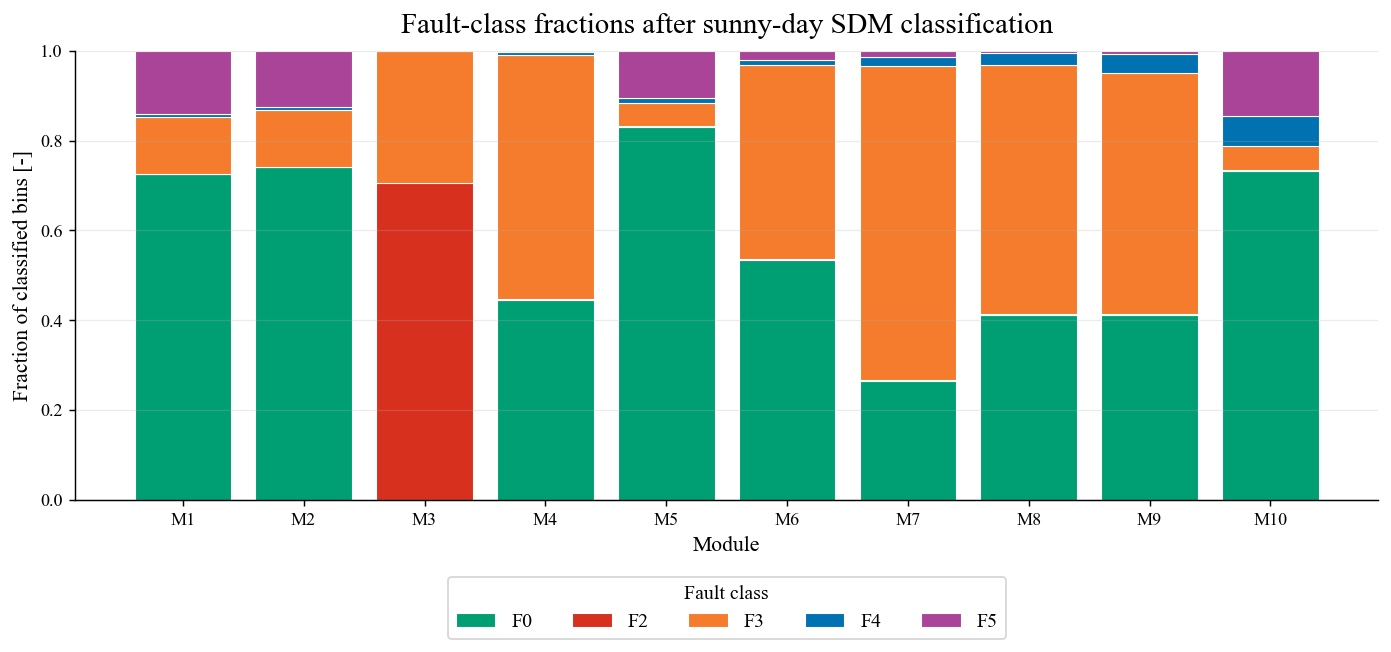

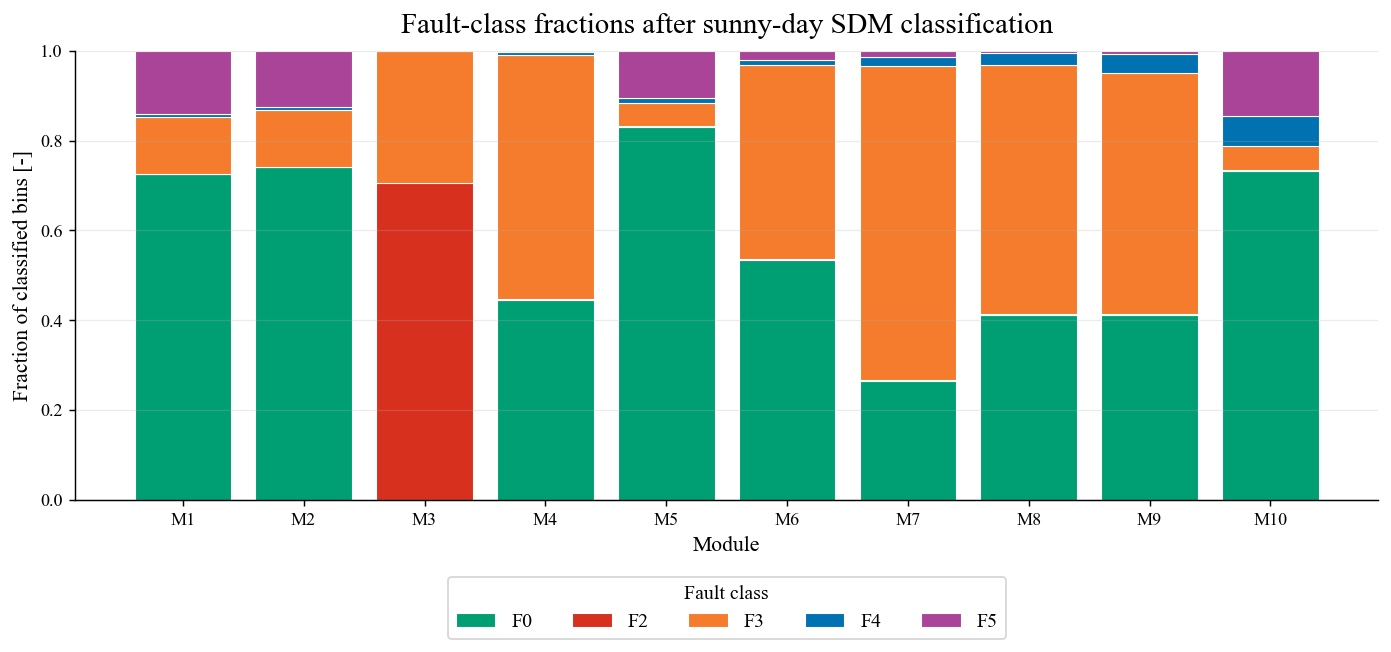

In [37]:
def plot_fault_class_fractions_by_module(
    fault_summary,
    save=True,
):
    plot_df = fault_summary.copy().set_index("Module_ID")

    for fault_class in CLASS_ORDER:
        if fault_class in plot_df.columns:
            plot_df[f"{fault_class}_fraction"] = (
                plot_df[fault_class] / plot_df["total_bins"]
            )

    fig, ax = plt.subplots(figsize=(10.8, 5.2))

    bottom = np.zeros(len(plot_df))
    x_labels = [f"M{int(m)}" for m in plot_df.index]

    for fault_class in FAULT_CLASSES_PLOT:
        values = plot_df[f"{fault_class}_fraction"].fillna(0).to_numpy()

        ax.bar(
            x_labels,
            values,
            bottom=bottom,
            color=FAULT_COLORS[fault_class],
            label=fault_class,
            edgecolor="white",
            linewidth=0.6,
        )

        bottom += values

    ax.set_title(
        "Fault-class fractions after sunny-day SDM classification",
        fontsize=TITLE_SIZE,
        pad=10,
    )

    ax.set_xlabel("Module", fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel("Fraction of classified bins [-]", fontsize=AXIS_LABEL_SIZE)

    ax.set_ylim(0, 1.0)
    ax.grid(axis="y", alpha=0.25)
    ax.grid(axis="x", visible=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        title="Fault class",
        ncol=5,
        frameon=True,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.15),
        fontsize=LEGEND_SIZE,
        title_fontsize=LEGEND_SIZE,
    )

    fig.tight_layout()

    if save:
        save_fig("shading_fault_class_fractions_by_module.png", fig)

    plt.show()
    return fig


plot_fault_class_fractions_by_module(fault_summary_by_module)

In [38]:
fault_summary_by_module_month = pd.crosstab(
    index=[
        df_classified["Module_ID"],
        df_classified["Type"],
        df_classified["Year"],
        df_classified["Month"],
    ],
    columns=df_classified["fault_class"],
)

fault_summary_by_module_month = fault_summary_by_module_month.reindex(
    columns=CLASS_ORDER,
    fill_value=0,
)

fault_summary_by_module_month["total_bins"] = fault_summary_by_module_month.sum(axis=1)

fault_summary_by_module_month["F0_fraction"] = (
    fault_summary_by_module_month["F0"] / fault_summary_by_module_month["total_bins"]
)

fault_summary_by_module_month["fault_candidate_fraction"] = (
    fault_summary_by_module_month[["F2", "F3", "F4", "F5"]].sum(axis=1)
    / fault_summary_by_module_month["total_bins"]
)

fault_summary_by_module_month = fault_summary_by_module_month.reset_index()

display(fault_summary_by_module_month.head())

fault_class,Module_ID,Type,Year,Month,F0,F1,F2,F3,F4,F5,SDM_FAILED,THRESHOLD_FAILED,UNCLASSIFIED,total_bins,F0_fraction,fault_candidate_fraction
0,1,PID/Reference,2017,1,100,0,0,1,5,56,0,0,0,162,0.617284,0.382716
1,1,PID/Reference,2017,2,47,0,0,0,0,10,0,0,0,57,0.824561,0.175439
2,1,PID/Reference,2017,3,30,0,0,0,0,4,0,0,0,34,0.882353,0.117647
3,1,PID/Reference,2017,4,180,0,0,7,2,78,0,0,0,267,0.674157,0.325843
4,1,PID/Reference,2017,5,403,0,0,13,1,81,0,0,0,498,0.809237,0.190763


Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\shading_module10_f0_and_fault_candidate_fraction_over_time.png


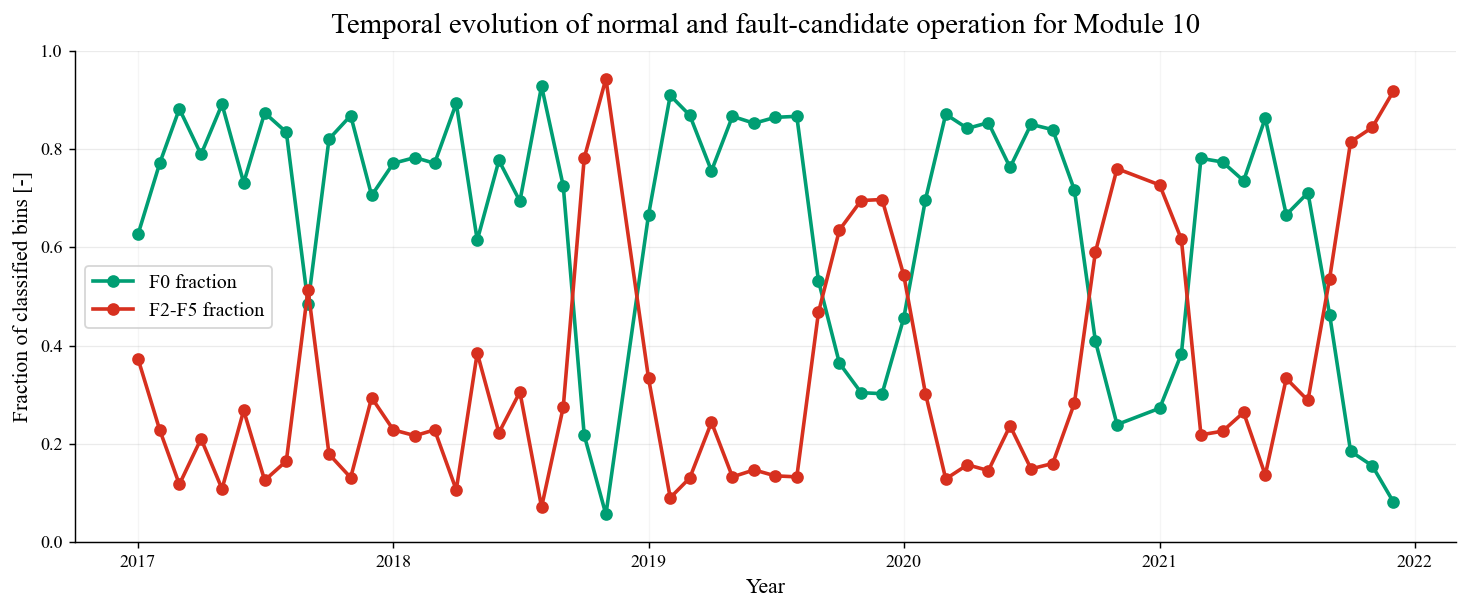

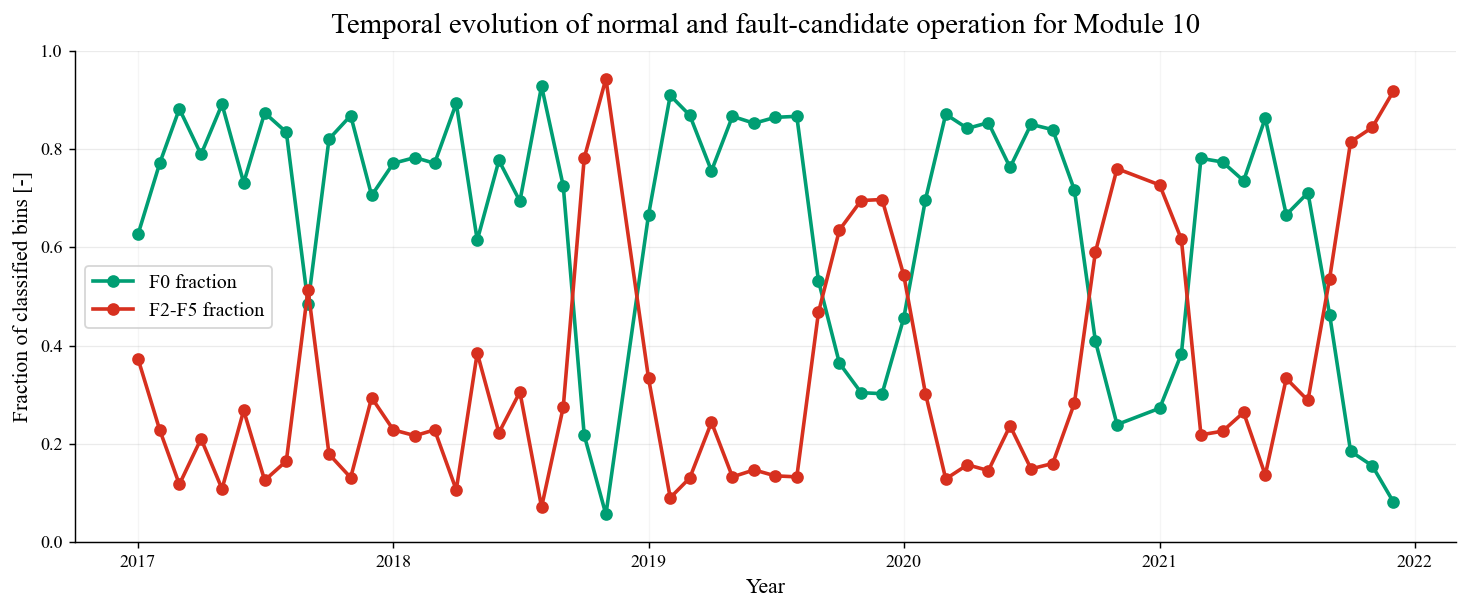

In [39]:
def plot_module10_f0_fault_fraction(
    fault_summary_month,
    save=True,
):
    plot_df = fault_summary_month.loc[
        fault_summary_month["Module_ID"] == 10
    ].copy()

    plot_df["YearMonth"] = pd.to_datetime(
        plot_df["Year"].astype(str)
        + "-"
        + plot_df["Month"].astype(str).str.zfill(2)
        + "-01"
    )

    plot_df = plot_df.sort_values("YearMonth")

    fig, ax = plt.subplots(figsize=(11.4, 4.8))

    ax.plot(
        plot_df["YearMonth"],
        plot_df["F0_fraction"],
        marker="o",
        linewidth=2.0,
        color=FAULT_COLORS["F0"],
        label="F0 fraction",
    )

    ax.plot(
        plot_df["YearMonth"],
        plot_df["fault_candidate_fraction"],
        marker="o",
        linewidth=2.0,
        color=FAULT_COLORS["F2"],
        label="F2-F5 fraction",
    )

    ax.set_title(
        "Temporal evolution of normal and fault-candidate operation for Module 10",
        fontsize=TITLE_SIZE,
        pad=10,
    )

    ax.set_xlabel("Year", fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel("Fraction of classified bins [-]", fontsize=AXIS_LABEL_SIZE)

    ax.set_ylim(0, 1.0)

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    ax.grid(axis="y", alpha=0.25)
    ax.grid(axis="x", alpha=0.12)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        frameon=True,
        loc="best",
        fontsize=LEGEND_SIZE,
    )

    fig.tight_layout()

    if save:
        save_fig("shading_module10_f0_and_fault_candidate_fraction_over_time.png", fig)

    plt.show()
    return fig


plot_module10_f0_fault_fraction(fault_summary_by_module_month)

## 14. Create F0-only intrinsic dataset

The F0-only dataset retains only bins classified as normal operation. This is used to calculate a diagnostic intrinsic PLR after removing detected non-normal operating periods.

In [40]:
df_f0_intrinsic = (
    df_classified
    .loc[df_classified["fault_class"] == "F0"]
    .copy()
    .sort_values(["Module_ID", "Datetime_Bin_Local"])
    .reset_index(drop=True)
)

print("Classified dataset:", df_classified.shape)
print("F0-only intrinsic dataset:", df_f0_intrinsic.shape)

f0_retention_summary = (
    df_classified
    .groupby(["Module_ID", "Type"], as_index=False)
    .agg(
        total_bins=("fault_class", "size"),
        f0_bins=("is_f0_intrinsic", "sum"),
        fault_candidate_bins=("is_fault_candidate", "sum"),
        first_datetime=("Datetime_Bin_Local", "min"),
        last_datetime=("Datetime_Bin_Local", "max"),
        n_days=("Date", "nunique"),
    )
)

f0_retention_summary["F0_fraction"] = (
    f0_retention_summary["f0_bins"] / f0_retention_summary["total_bins"]
)

f0_retention_summary["fault_candidate_fraction"] = (
    f0_retention_summary["fault_candidate_bins"] / f0_retention_summary["total_bins"]
)

display(f0_retention_summary)

Classified dataset: (149406, 48)
F0-only intrinsic dataset: (76527, 48)


,Module_ID,Type,total_bins,f0_bins,fault_candidate_bins,first_datetime,last_datetime,n_days,F0_fraction,fault_candidate_fraction
0,1,PID/Reference,15029,10901,4128,2017-01-02 10:15:00+01:00,2021-12-27 14:45:00+01:00,427,0.725331,0.274669
1,2,Reference,15030,11143,3887,2017-01-02 10:15:00+01:00,2021-12-27 14:45:00+01:00,427,0.741384,0.258616
2,3,uCrack,14237,2,14235,2017-01-02 10:15:00+01:00,2021-12-27 14:45:00+01:00,427,0.000140,0.999860
3,4,uCrack,15033,6680,8353,2017-01-02 10:15:00+01:00,2021-12-27 14:45:00+01:00,427,0.444356,0.555644
4,5,Reference,15026,12484,2542,2017-01-02 10:15:00+01:00,2021-12-27 14:45:00+01:00,427,0.830827,0.169173
5,6,uCrack,15035,8016,7019,2017-01-02 10:15:00+01:00,2021-12-27 14:45:00+01:00,427,0.533156,0.466844
6,7,uCrack,15011,3960,11051,2017-01-02 10:15:00+01:00,2021-12-27 14:45:00+01:00,427,0.263807,0.736193
7,8,uCrack,15023,6190,8833,2017-01-02 10:15:00+01:00,2021-12-27 14:45:00+01:00,427,0.412035,0.587965
8,9,uCrack,14996,6168,8828,2017-01-02 10:15:00+01:00,2021-12-27 14:45:00+01:00,427,0.411310,0.588690
9,10,Reference,14986,10983,4003,2017-01-02 10:15:00+01:00,2021-12-27 14:45:00+01:00,427,0.732884,0.267116


## 15. Aggregate F0-only daily and monthly \(PR_\mathrm{DC,25C}\)

F0-only daily and monthly performance ratios are calculated using the same yield-based ratio-of-sums logic used in the PLR pipeline.

In [41]:
def safe_scalar_ratio(numerator, denominator):
    if pd.isna(denominator) or denominator <= 0:
        return np.nan
    return numerator / denominator


def aggregate_f0_one_day(group):
    energy_raw_wh = (group["P_MPP"] * BIN_HOURS).sum()
    energy_25c_wh = (group["P_MPP_25C"] * BIN_HOURS).sum()

    reference_energy_wh = (
        group["P_STC"]
        * (group["G_POA"] / G_STC)
        * BIN_HOURS
    ).sum()

    return pd.Series({
        "PR_25C": safe_scalar_ratio(energy_25c_wh, reference_energy_wh),
        "PR_raw": safe_scalar_ratio(energy_raw_wh, reference_energy_wh),
        "energy_raw_Wh": energy_raw_wh,
        "energy_25C_Wh": energy_25c_wh,
        "reference_energy_Wh": reference_energy_wh,
        "n_bins_day": group["Datetime_Bin_Local"].nunique(),
        "median_G_POA": group["G_POA"].median(),
    })


required_f0_cols = [
    "Module_ID",
    "Type",
    "Date",
    "Datetime_Bin_Local",
    "G_POA",
    "P_MPP",
    "P_MPP_25C",
    "P_STC",
]

missing_f0_cols = [col for col in required_f0_cols if col not in df_f0_intrinsic.columns]

if missing_f0_cols:
    raise KeyError(f"Missing columns required for intrinsic aggregation: {missing_f0_cols}")

f0_daily = (
    df_f0_intrinsic
    .dropna(subset=required_f0_cols)
    .groupby(["Module_ID", "Type", "Date"])
    .apply(aggregate_f0_one_day)
    .reset_index()
    .sort_values(["Module_ID", "Date"])
    .reset_index(drop=True)
)

f0_daily["day_valid_for_intrinsic_plr"] = (
    f0_daily["n_bins_day"] >= MIN_BINS_DAY_INTRINSIC
)

display(f0_daily.head())

,Module_ID,Type,Date,PR_25C,PR_raw,energy_raw_Wh,energy_25C_Wh,reference_energy_Wh,n_bins_day,median_G_POA,day_valid_for_intrinsic_plr
0,1,PID/Reference,2017-01-02,1.008618,1.052620,244.791589,234.558743,232.554620,10.0,705.176409,True
1,1,PID/Reference,2017-01-05,0.991495,1.058531,175.074448,163.986977,165.393729,6.0,753.499783,False
2,1,PID/Reference,2017-01-06,1.003714,1.055310,263.210910,250.342138,249.415798,10.0,723.953128,True
3,1,PID/Reference,2017-01-16,1.013648,1.044171,482.654224,468.545269,462.236826,18.0,733.895025,True
4,1,PID/Reference,2017-01-20,1.007590,1.041676,338.605847,327.526053,325.058800,16.0,576.194662,True


In [42]:
f0_daily_valid = f0_daily.loc[
    f0_daily["day_valid_for_intrinsic_plr"]
].copy()

f0_daily_valid["Month_Start"] = pd.to_datetime(
    f0_daily_valid["Date"]
).values.astype("datetime64[M]")

f0_daily_valid["YearMonth"] = (
    f0_daily_valid["Month_Start"]
    .dt.to_period("M")
    .astype(str)
)


def aggregate_f0_one_month(group):
    energy_raw_wh = group["energy_raw_Wh"].sum()
    energy_25c_wh = group["energy_25C_Wh"].sum()
    reference_energy_wh = group["reference_energy_Wh"].sum()

    return pd.Series({
        "PR_25C": safe_scalar_ratio(energy_25c_wh, reference_energy_wh),
        "PR_raw": safe_scalar_ratio(energy_raw_wh, reference_energy_wh),
        "energy_raw_Wh": energy_raw_wh,
        "energy_25C_Wh": energy_25c_wh,
        "reference_energy_Wh": reference_energy_wh,
        "n_days_month": group["Date"].nunique(),
        "median_bins_per_day": group["n_bins_day"].median(),
    })


f0_monthly = (
    f0_daily_valid
    .groupby(["Module_ID", "Type", "Month_Start", "YearMonth"])
    .apply(aggregate_f0_one_month)
    .reset_index()
    .sort_values(["Module_ID", "Month_Start"])
    .reset_index(drop=True)
)

f0_monthly["month_valid_for_intrinsic_plr"] = (
    f0_monthly["n_days_month"] >= MIN_DAYS_MONTH_INTRINSIC
)

f0_monthly_valid = (
    f0_monthly
    .loc[f0_monthly["month_valid_for_intrinsic_plr"]]
    .copy()
    .reset_index(drop=True)
)

display(f0_monthly_valid.head())

,Module_ID,Type,Month_Start,YearMonth,PR_25C,PR_raw,energy_raw_Wh,energy_25C_Wh,reference_energy_Wh,n_days_month,median_bins_per_day,month_valid_for_intrinsic_plr
0,1,PID/Reference,2017-05-01,2017-05,0.979386,0.944237,9765.772968,10129.307985,10342.504500,14.0,30.5,True
1,1,PID/Reference,2017-08-01,2017-08,0.981767,0.947496,6425.717187,6658.133234,6781.785902,11.0,27.0,True
2,1,PID/Reference,2018-05-01,2018-05,0.983953,0.925514,9147.129149,9724.692055,9883.291212,12.0,32.0,True
3,1,PID/Reference,2018-06-01,2018-06,0.998013,0.939217,10587.588594,11250.388964,11272.785553,15.0,30.0,True
4,1,PID/Reference,2018-07-01,2018-07,0.988491,0.914903,14450.942317,15613.270525,15795.048643,19.0,32.0,True


## 16. Fit F0-only intrinsic SLR

Intrinsic PLR is calculated only for modules with sufficient F0 monthly support. This result is diagnostic because the F0-only screening substantially reduces the available monthly record.

In [43]:
f0_slr_eligibility = (
    f0_monthly_valid
    .groupby(["Module_ID", "Type"], as_index=False)
    .agg(
        n_months=("Month_Start", "nunique"),
        first_month=("Month_Start", "min"),
        last_month=("Month_Start", "max"),
        median_monthly_PR_25C=("PR_25C", "median"),
        median_n_days_month=("n_days_month", "median"),
    )
)

f0_slr_eligibility["time_span_years"] = (
    (f0_slr_eligibility["last_month"] - f0_slr_eligibility["first_month"]).dt.days
    / DAYS_PER_YEAR
)

f0_slr_eligibility["SLR_possible"] = (
    f0_slr_eligibility["n_months"] >= MIN_MONTHS_FOR_INTRINSIC_SLR
)

display(f0_slr_eligibility)

eligible_modules = (
    f0_slr_eligibility
    .loc[f0_slr_eligibility["SLR_possible"], "Module_ID"]
    .astype(int)
    .tolist()
)

print("Eligible modules for F0-only intrinsic SLR:", eligible_modules)

,Module_ID,Type,n_months,first_month,last_month,median_monthly_PR_25C,median_n_days_month,time_span_years,SLR_possible
0,1,PID/Reference,15,2017-05-01,2021-09-01,0.971560,14.0,4.336756,True
1,2,Reference,15,2017-05-01,2021-04-01,0.975090,14.0,3.917864,True
2,4,uCrack,8,2017-05-01,2021-03-01,0.926736,12.0,3.832991,False
3,5,Reference,16,2017-05-01,2021-09-01,0.984841,14.0,4.336756,True
4,6,uCrack,10,2018-07-01,2021-04-01,0.946497,13.5,2.751540,False
5,7,uCrack,2,2020-03-01,2020-04-01,0.942124,12.0,0.084873,False
6,8,uCrack,5,2019-06-01,2021-03-01,0.922835,12.0,1.749487,False
7,9,uCrack,7,2017-05-01,2021-03-01,0.933975,11.0,3.832991,False
8,10,Reference,14,2017-05-01,2021-04-01,0.973937,14.0,3.917864,True


Eligible modules for F0-only intrinsic SLR: [1, 2, 5, 10]


In [45]:
intrinsic_slr_model_df = (
    f0_monthly_valid
    .loc[f0_monthly_valid["Module_ID"].isin(eligible_modules)]
    .copy()
    .sort_values(["Module_ID", "Month_Start"])
    .reset_index(drop=True)
)

intrinsic_slr_model_df["dataset"] = "f0_intrinsic"
intrinsic_slr_model_df["dataset_label"] = "F0-only intrinsic"

intrinsic_slr_model_df["module_start_month"] = (
    intrinsic_slr_model_df
    .groupby("Module_ID")["Month_Start"]
    .transform("min")
)

intrinsic_slr_model_df["time_days"] = (
    intrinsic_slr_model_df["Month_Start"]
    - intrinsic_slr_model_df["module_start_month"]
).dt.days

intrinsic_slr_model_df["time_years"] = (
    intrinsic_slr_model_df["time_days"] / DAYS_PER_YEAR
)

display(intrinsic_slr_model_df.head())

,Module_ID,Type,Month_Start,YearMonth,PR_25C,PR_raw,energy_raw_Wh,energy_25C_Wh,reference_energy_Wh,n_days_month,median_bins_per_day,month_valid_for_intrinsic_plr,dataset,dataset_label,module_start_month,time_days,time_years
0,1,PID/Reference,2017-05-01,2017-05,0.979386,0.944237,9765.772968,10129.307985,10342.504500,14.0,30.5,True,f0_intrinsic,F0-only intrinsic,2017-05-01,0,0.000000
1,1,PID/Reference,2017-08-01,2017-08,0.981767,0.947496,6425.717187,6658.133234,6781.785902,11.0,27.0,True,f0_intrinsic,F0-only intrinsic,2017-05-01,92,0.251882
2,1,PID/Reference,2018-05-01,2018-05,0.983953,0.925514,9147.129149,9724.692055,9883.291212,12.0,32.0,True,f0_intrinsic,F0-only intrinsic,2017-05-01,365,0.999316
3,1,PID/Reference,2018-06-01,2018-06,0.998013,0.939217,10587.588594,11250.388964,11272.785553,15.0,30.0,True,f0_intrinsic,F0-only intrinsic,2017-05-01,396,1.084189
4,1,PID/Reference,2018-07-01,2018-07,0.988491,0.914903,14450.942317,15613.270525,15795.048643,19.0,32.0,True,f0_intrinsic,F0-only intrinsic,2017-05-01,426,1.166324


In [46]:
intrinsic_slr_model_df = (
    f0_monthly_valid
    .loc[f0_monthly_valid["Module_ID"].isin(eligible_modules)]
    .copy()
    .sort_values(["Module_ID", "Month_Start"])
    .reset_index(drop=True)
)

intrinsic_slr_model_df["dataset"] = "f0_intrinsic"
intrinsic_slr_model_df["dataset_label"] = "F0-only intrinsic"

intrinsic_slr_model_df["module_start_month"] = (
    intrinsic_slr_model_df
    .groupby("Module_ID")["Month_Start"]
    .transform("min")
)

intrinsic_slr_model_df["time_days"] = (
    intrinsic_slr_model_df["Month_Start"]
    - intrinsic_slr_model_df["module_start_month"]
).dt.days

intrinsic_slr_model_df["time_years"] = (
    intrinsic_slr_model_df["time_days"] / DAYS_PER_YEAR
)

display(intrinsic_slr_model_df.head())

,Module_ID,Type,Month_Start,YearMonth,PR_25C,PR_raw,energy_raw_Wh,energy_25C_Wh,reference_energy_Wh,n_days_month,median_bins_per_day,month_valid_for_intrinsic_plr,dataset,dataset_label,module_start_month,time_days,time_years
0,1,PID/Reference,2017-05-01,2017-05,0.979386,0.944237,9765.772968,10129.307985,10342.504500,14.0,30.5,True,f0_intrinsic,F0-only intrinsic,2017-05-01,0,0.000000
1,1,PID/Reference,2017-08-01,2017-08,0.981767,0.947496,6425.717187,6658.133234,6781.785902,11.0,27.0,True,f0_intrinsic,F0-only intrinsic,2017-05-01,92,0.251882
2,1,PID/Reference,2018-05-01,2018-05,0.983953,0.925514,9147.129149,9724.692055,9883.291212,12.0,32.0,True,f0_intrinsic,F0-only intrinsic,2017-05-01,365,0.999316
3,1,PID/Reference,2018-06-01,2018-06,0.998013,0.939217,10587.588594,11250.388964,11272.785553,15.0,30.0,True,f0_intrinsic,F0-only intrinsic,2017-05-01,396,1.084189
4,1,PID/Reference,2018-07-01,2018-07,0.988491,0.914903,14450.942317,15613.270525,15795.048643,19.0,32.0,True,f0_intrinsic,F0-only intrinsic,2017-05-01,426,1.166324


In [48]:
def fit_intrinsic_slr_for_module(module_df):
    module_df = module_df.sort_values("Month_Start").copy()

    module_id = int(module_df["Module_ID"].iloc[0])
    module_type = module_df["Type"].iloc[0]

    y = module_df["PR_25C"].astype(float)
    X = sm.add_constant(module_df["time_years"].astype(float))

    model = sm.OLS(y, X).fit()

    beta_0 = model.params["const"]
    beta_1 = model.params["time_years"]

    beta_1_ci_low, beta_1_ci_high = model.conf_int(alpha=ALPHA).loc["time_years"]

    plr = 100 * beta_1 / beta_0
    plr_ci_low = 100 * beta_1_ci_low / beta_0
    plr_ci_high = 100 * beta_1_ci_high / beta_0
    plr_se = 100 * model.bse["time_years"] / beta_0

    plr_ci_low, plr_ci_high = sorted([plr_ci_low, plr_ci_high])

    pred = model.get_prediction(X).summary_frame(alpha=ALPHA)

    prediction_df = module_df.copy()
    prediction_df["SLR_fit"] = pred["mean"].to_numpy()
    prediction_df["SLR_fit_ci_lower"] = pred["mean_ci_lower"].to_numpy()
    prediction_df["SLR_fit_ci_upper"] = pred["mean_ci_upper"].to_numpy()

    result = {
        "dataset": "f0_intrinsic",
        "Module_ID": module_id,
        "Type": module_type,
        "n_months": len(module_df),
        "first_month": module_df["Month_Start"].min(),
        "last_month": module_df["Month_Start"].max(),
        "time_span_years": module_df["time_years"].max() - module_df["time_years"].min(),
        "intercept_PR_25C": beta_0,
        "slope_abs_per_year": beta_1,
        "PLR_intrinsic_pct_per_year": plr,
        "PLR_intrinsic_se_pct_per_year": plr_se,
        "PLR_intrinsic_ci_low_pct_per_year": plr_ci_low,
        "PLR_intrinsic_ci_high_pct_per_year": plr_ci_high,
        "p_value_slope": model.pvalues["time_years"],
        "r_squared": model.rsquared,
    }

    return result, prediction_df

In [49]:
intrinsic_rows = []
intrinsic_prediction_tables = []

for module_id, module_df in intrinsic_slr_model_df.groupby("Module_ID"):
    result, pred_df = fit_intrinsic_slr_for_module(module_df)

    intrinsic_rows.append(result)
    intrinsic_prediction_tables.append(pred_df)

intrinsic_slr_results = (
    pd.DataFrame(intrinsic_rows)
    .sort_values("Module_ID")
    .reset_index(drop=True)
)

intrinsic_slr_predictions = (
    pd.concat(intrinsic_prediction_tables, ignore_index=True)
    .sort_values(["Module_ID", "Month_Start"])
    .reset_index(drop=True)
)

display(intrinsic_slr_results)

,dataset,Module_ID,Type,n_months,first_month,last_month,time_span_years,intercept_PR_25C,slope_abs_per_year,PLR_intrinsic_pct_per_year,PLR_intrinsic_se_pct_per_year,PLR_intrinsic_ci_low_pct_per_year,PLR_intrinsic_ci_high_pct_per_year,p_value_slope,r_squared
0,f0_intrinsic,1,PID/Reference,15,2017-05-01,2021-09-01,4.336756,0.988080,-0.005149,-0.521066,0.132908,-0.808197,-0.233935,0.001757,0.541773
1,f0_intrinsic,2,Reference,15,2017-05-01,2021-04-01,3.917864,0.980676,-0.002864,-0.292078,0.179819,-0.680555,0.096398,0.128302,0.168708
2,f0_intrinsic,5,Reference,16,2017-05-01,2021-09-01,4.336756,1.000669,-0.005148,-0.514410,0.191672,-0.925506,-0.103314,0.017813,0.339710
3,f0_intrinsic,10,Reference,14,2017-05-01,2021-04-01,3.917864,0.989331,-0.006230,-0.629685,0.156115,-0.969831,-0.289540,0.001659,0.575506


## 17. Plot F0-only intrinsic SLR trends

This figure shows the F0-only intrinsic SLR fits for modules with sufficient F0 monthly support.

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\intrinsic_f0_only_slr_trends_monthly_prdc25c.png


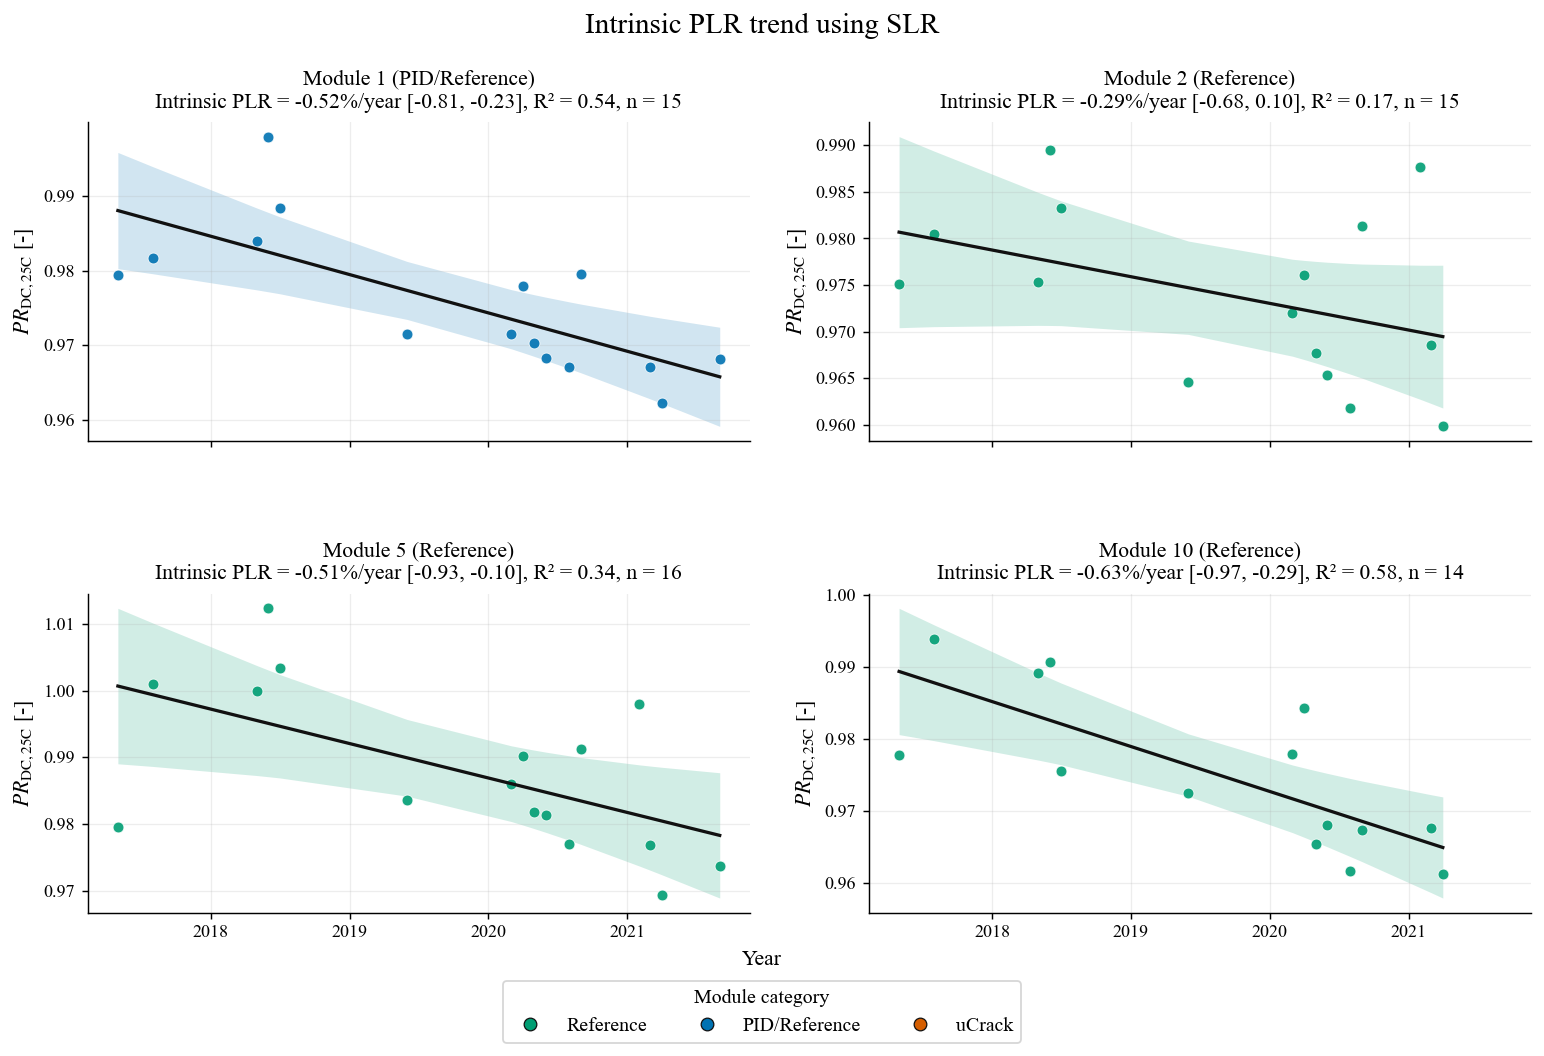

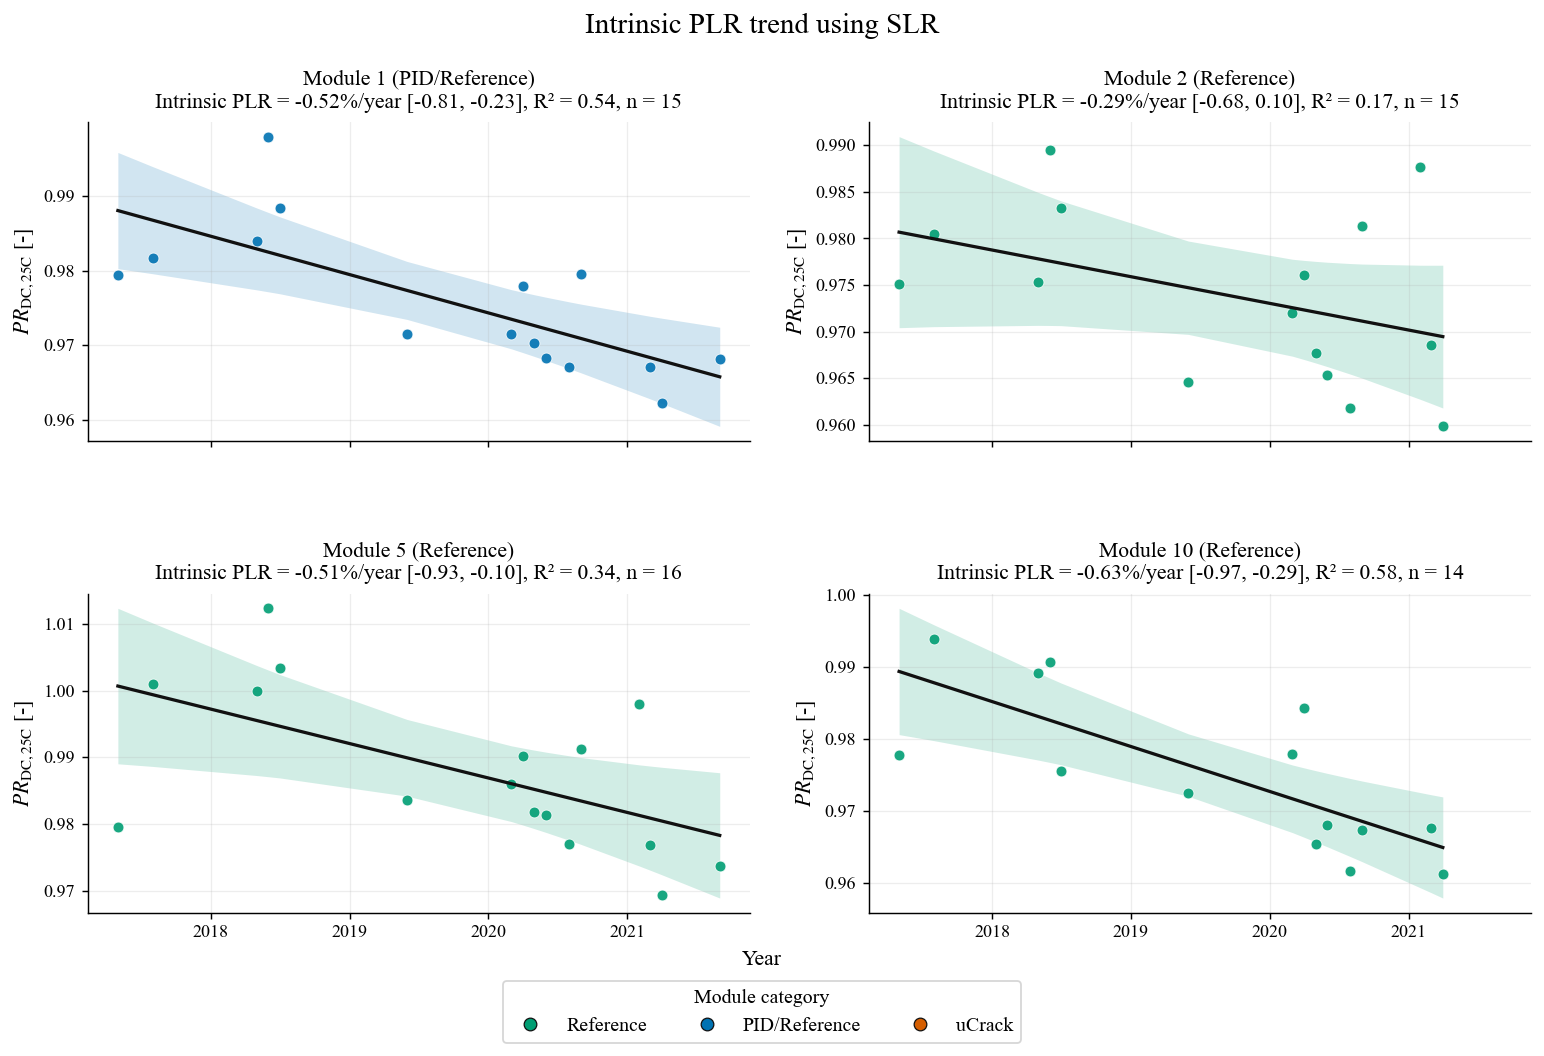

In [53]:
def plot_intrinsic_slr_trends(
    intrinsic_predictions,
    intrinsic_results,
    save=True,
):
    module_ids = sorted(intrinsic_predictions["Module_ID"].unique())

    n_modules = len(module_ids)

    if n_modules == 0:
        raise ValueError("No modules available for intrinsic SLR plotting.")

    ncols = 2
    nrows = int(np.ceil(n_modules / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(12.2, 4.0 * nrows),
        sharex=True,
    )

    axes = np.array(axes).reshape(-1)

    for ax, module_id in zip(axes, module_ids):
        module_data = (
            intrinsic_predictions
            .loc[intrinsic_predictions["Module_ID"] == module_id]
            .sort_values("Month_Start")
            .copy()
        )

        result = intrinsic_results.loc[
            intrinsic_results["Module_ID"] == module_id
        ].iloc[0]

        module_type = module_data["Type"].iloc[0]
        color = TYPE_COLORS.get(module_type, TYPE_COLORS["Unknown"])

        plr = result["PLR_intrinsic_pct_per_year"]
        ci_low = result["PLR_intrinsic_ci_low_pct_per_year"]
        ci_high = result["PLR_intrinsic_ci_high_pct_per_year"]
        r2 = result["r_squared"]
        n_months = int(result["n_months"])

        ax.scatter(
            module_data["Month_Start"],
            module_data["PR_25C"],
            s=36,
            color=color,
            edgecolor="white",
            linewidth=0.45,
            alpha=0.90,
            zorder=3,
        )

        ax.fill_between(
            module_data["Month_Start"],
            module_data["SLR_fit_ci_lower"],
            module_data["SLR_fit_ci_upper"],
            color=color,
            alpha=0.18,
            linewidth=0,
            zorder=1,
        )

        ax.plot(
            module_data["Month_Start"],
            module_data["SLR_fit"],
            color=BLACK,
            linewidth=1.8,
            zorder=4,
        )

        ax.set_title(
            f"Module {module_id} ({module_type})\n"
            f"Intrinsic PLR = {plr:.2f}%/year [{ci_low:.2f}, {ci_high:.2f}], "
            f"R² = {r2:.2f}, n = {n_months}",
            fontsize=SUBTITLE_SIZE,
            pad=8,
        )

        ax.set_ylabel(r"$PR_\mathrm{DC,25C}$ [-]", fontsize=AXIS_LABEL_SIZE)

        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

        ax.grid(alpha=0.22)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    for ax in axes[n_modules:]:
        ax.axis("off")

    fig.suptitle(
        "Intrinsic PLR trend using SLR",
        fontsize=TITLE_SIZE,
        y=0.985,
    )

    fig.supxlabel("Year", fontsize=AXIS_LABEL_SIZE, y=0.065)

    fig.legend(
        handles=module_category_marker_handles(),
        title="Module category",
        loc="lower center",
        ncol=3,
        frameon=True,
        bbox_to_anchor=(0.5, -0.015),
        fontsize=LEGEND_SIZE,
        title_fontsize=LEGEND_SIZE,
    )

    fig.subplots_adjust(
        left=0.075,
        right=0.985,
        top=0.88,
        bottom=0.12,
        hspace=0.48,
        wspace=0.18,
    )

    if save:
        save_fig("intrinsic_f0_only_slr_trends_monthly_prdc25c.png", fig)

    plt.show()
    return fig


plot_intrinsic_slr_trends(
    intrinsic_predictions=intrinsic_slr_predictions,
    intrinsic_results=intrinsic_slr_results,
    save=True,
)

## 18. Compare primary apparent PLR and F0-only intrinsic PLR

The F0-only intrinsic PLR is compared with the primary YoY-STL ensemble where available. This comparison tests whether detected fault-candidate periods make the apparent PLR more negative.

In [54]:
def load_primary_ensemble(path):
    """
    Load primary ensemble output.
    """
    if not path.exists():
        print("Primary ensemble file not found. Comparison table will use intrinsic results only.")
        return pd.DataFrame()

    df = pd.read_csv(path)

    module_col = "Module_ID"

    plr_col_candidates = [
        "PLR_ensemble_pct_per_year",
        "Primary_ensemble_PLR",
        "primary_PLR",
    ]

    low_col_candidates = [
        "PLR_ensemble_ci_low",
        "Primary_ensemble_ci_low",
        "primary_ci_low",
    ]

    high_col_candidates = [
        "PLR_ensemble_ci_high",
        "Primary_ensemble_ci_high",
        "primary_ci_high",
    ]

    plr_col = next((col for col in plr_col_candidates if col in df.columns), None)
    low_col = next((col for col in low_col_candidates if col in df.columns), None)
    high_col = next((col for col in high_col_candidates if col in df.columns), None)

    if plr_col is None or low_col is None or high_col is None:
        print("Primary ensemble file found, but expected PLR columns were not found.")
        print(df.columns.tolist())
        return pd.DataFrame()

    out = df[[module_col, plr_col, low_col, high_col]].copy()

    out = out.rename(
        columns={
            plr_col: "Primary_ensemble_PLR_pct_per_year",
            low_col: "Primary_ensemble_ci_low_pct_per_year",
            high_col: "Primary_ensemble_ci_high_pct_per_year",
        }
    )

    out["Module_ID"] = out["Module_ID"].astype(int)

    return out


primary_ensemble = load_primary_ensemble(PRIMARY_ENSEMBLE_PATH)

display(primary_ensemble.head())

,Module_ID,Primary_ensemble_PLR_pct_per_year,Primary_ensemble_ci_low_pct_per_year,Primary_ensemble_ci_high_pct_per_year
0,1,-0.322794,-0.414751,-0.231297
1,2,-0.285594,-0.381903,-0.189261
2,3,-0.250867,-0.427191,-0.075461
3,4,-0.343723,-0.434760,-0.253108
4,5,-0.313317,-0.400670,-0.225206


In [55]:
intrinsic_comparison = intrinsic_slr_results.copy()

if not primary_ensemble.empty:
    intrinsic_comparison = intrinsic_comparison.merge(
        primary_ensemble,
        on="Module_ID",
        how="left",
    )

    intrinsic_comparison["Intrinsic_minus_primary_PLR_pct_per_year"] = (
        intrinsic_comparison["PLR_intrinsic_pct_per_year"]
        - intrinsic_comparison["Primary_ensemble_PLR_pct_per_year"]
    )

display(intrinsic_comparison)

,dataset,Module_ID,Type,n_months,first_month,last_month,time_span_years,intercept_PR_25C,slope_abs_per_year,PLR_intrinsic_pct_per_year,PLR_intrinsic_se_pct_per_year,PLR_intrinsic_ci_low_pct_per_year,PLR_intrinsic_ci_high_pct_per_year,p_value_slope,r_squared,Primary_ensemble_PLR_pct_per_year,Primary_ensemble_ci_low_pct_per_year,Primary_ensemble_ci_high_pct_per_year,Intrinsic_minus_primary_PLR_pct_per_year
0,f0_intrinsic,1,PID/Reference,15,2017-05-01,2021-09-01,4.336756,0.988080,-0.005149,-0.521066,0.132908,-0.808197,-0.233935,0.001757,0.541773,-0.322794,-0.414751,-0.231297,-0.198272
1,f0_intrinsic,2,Reference,15,2017-05-01,2021-04-01,3.917864,0.980676,-0.002864,-0.292078,0.179819,-0.680555,0.096398,0.128302,0.168708,-0.285594,-0.381903,-0.189261,-0.006484
2,f0_intrinsic,5,Reference,16,2017-05-01,2021-09-01,4.336756,1.000669,-0.005148,-0.514410,0.191672,-0.925506,-0.103314,0.017813,0.339710,-0.313317,-0.400670,-0.225206,-0.201094
3,f0_intrinsic,10,Reference,14,2017-05-01,2021-04-01,3.917864,0.989331,-0.006230,-0.629685,0.156115,-0.969831,-0.289540,0.001659,0.575506,-1.453216,-1.575121,-1.331671,0.823530


Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\intrinsic_vs_primary_ensemble_plr_comparison.png


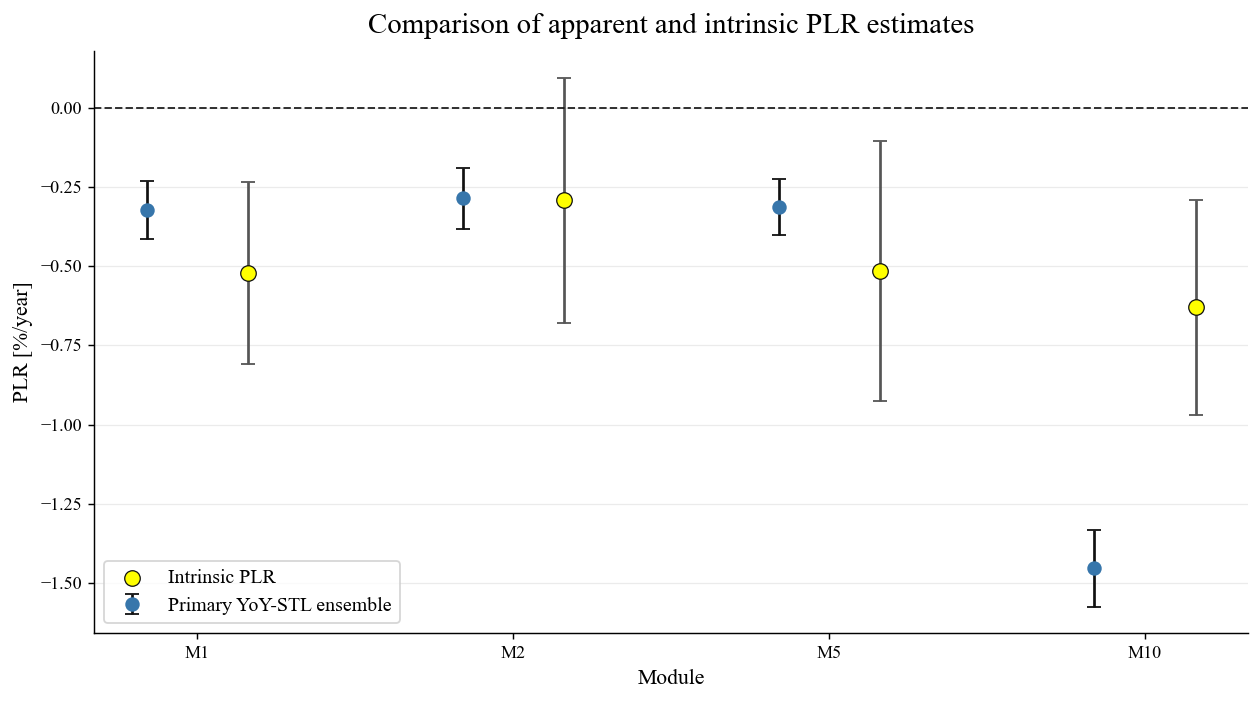

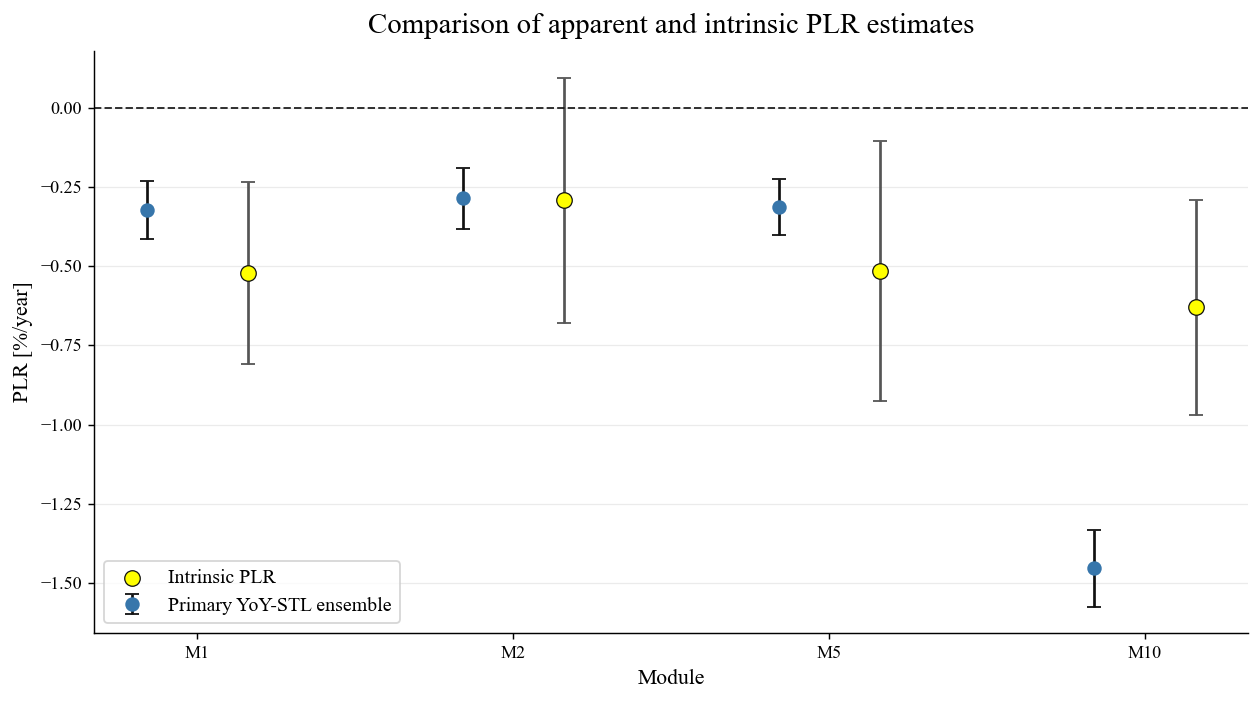

In [58]:
BLUE = "#3776ab"
YELLOW = "#FFFF00"
def plot_intrinsic_vs_primary_plr(
    comparison_df,
    save=True,
):
    if "Primary_ensemble_PLR_pct_per_year" not in comparison_df.columns:
        print("Primary ensemble columns not available. Skipping comparison plot.")
        return None

    plot_df = comparison_df.dropna(
        subset=[
            "Primary_ensemble_PLR_pct_per_year",
            "PLR_intrinsic_pct_per_year",
        ]
    ).copy()

    if plot_df.empty:
        print("No overlapping primary and intrinsic PLR data available.")
        return None

    fig, ax = plt.subplots(figsize=(9.8, 5.5))

    x = np.arange(len(plot_df))
    width = 0.32

    primary_y = plot_df["Primary_ensemble_PLR_pct_per_year"].to_numpy()
    primary_err_low = primary_y - plot_df["Primary_ensemble_ci_low_pct_per_year"].to_numpy()
    primary_err_high = plot_df["Primary_ensemble_ci_high_pct_per_year"].to_numpy() - primary_y

    intrinsic_y = plot_df["PLR_intrinsic_pct_per_year"].to_numpy()
    intrinsic_err_low = intrinsic_y - plot_df["PLR_intrinsic_ci_low_pct_per_year"].to_numpy()
    intrinsic_err_high = plot_df["PLR_intrinsic_ci_high_pct_per_year"].to_numpy() - intrinsic_y

    ax.errorbar(
        x - width / 2,
        primary_y,
        yerr=[primary_err_low, primary_err_high],
        fmt="o",
        color=BLUE,
        ecolor=BLACK,
        capsize=4,
        markersize=7,
        label="Primary YoY-STL ensemble",
        zorder=3,
    )

    colors = plot_df["Type"].map(TYPE_COLORS).fillna(TYPE_COLORS["Unknown"]).to_list()

    ax.errorbar(
        x + width / 2,
        intrinsic_y,
        yerr=[intrinsic_err_low, intrinsic_err_high],
        fmt="o",
        color=DARK_GREY,
        ecolor=DARK_GREY,
        capsize=4,
        markersize=0,
        zorder=2,
    )

    ax.scatter(
        x + width / 2,
        intrinsic_y,
        s=74,
        color=YELLOW,
        edgecolor=BLACK,
        linewidth=0.7,
        label="Intrinsic PLR",
        zorder=4,
    )

    ax.axhline(
        0,
        color=BLACK,
        linestyle="--",
        linewidth=1.1,
        alpha=0.85,
    )

    ax.set_xticks(x)
    ax.set_xticklabels([f"M{int(m)}" for m in plot_df["Module_ID"]])

    ax.set_xlabel("Module", fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel("PLR [%/year]", fontsize=AXIS_LABEL_SIZE)

    ax.set_title(
        "Comparison of apparent and intrinsic PLR estimates",
        fontsize=TITLE_SIZE,
        pad=10,
    )

    ax.grid(axis="y", alpha=0.25)
    ax.grid(axis="x", visible=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        frameon=True,
        loc="best",
        fontsize=LEGEND_SIZE,
    )

    fig.tight_layout()

    if save:
        save_fig("intrinsic_vs_primary_ensemble_plr_comparison.png", fig)

    plt.show()
    return fig


plot_intrinsic_vs_primary_plr(intrinsic_comparison)

## 19. Save final outputs

Final classified datasets, summary tables, and intrinsic PLR outputs are saved for use in the results chapter.

In [59]:
df_classified.to_parquet(
    DATA_OUTPUT_DIR / "df_sunny_sdm_fault_classified_binned15.parquet",
    index=False,
)

df_f0_intrinsic.to_parquet(
    DATA_OUTPUT_DIR / "df_sunny_f0_intrinsic_binned15.parquet",
    index=False,
)

f0_daily.to_csv(
    FINAL_TABLE_DIR / "intrinsic_f0_daily_pr25c_before_filter.csv",
    index=False,
)

f0_daily_valid.to_csv(
    FINAL_TABLE_DIR / "intrinsic_f0_daily_pr25c_valid.csv",
    index=False,
)

f0_monthly.to_csv(
    FINAL_TABLE_DIR / "intrinsic_f0_monthly_pr25c_before_filter.csv",
    index=False,
)

f0_monthly_valid.to_csv(
    FINAL_TABLE_DIR / "intrinsic_f0_monthly_pr25c_valid.csv",
    index=False,
)

f0_retention_summary.to_csv(
    FINAL_TABLE_DIR / "intrinsic_f0_retention_summary_by_module.csv",
    index=False,
)

overall_fault_counts.to_csv(
    FINAL_TABLE_DIR / "shading_fault_class_summary_overall.csv",
    index=False,
)

fault_summary_by_module.to_csv(
    FINAL_TABLE_DIR / "shading_fault_class_summary_by_module.csv",
    index=False,
)

fault_summary_by_module_month.to_csv(
    FINAL_TABLE_DIR / "shading_fault_class_summary_by_module_month.csv",
    index=False,
)

sdm_ratio_summary.to_csv(
    FINAL_TABLE_DIR / "shading_sdm_measured_to_model_ratio_summary.csv",
    index=False,
)

intrinsic_slr_results.to_csv(
    FINAL_TABLE_DIR / "intrinsic_f0_only_slr_plr_results.csv",
    index=False,
)

intrinsic_slr_predictions.to_parquet(
    DATA_OUTPUT_DIR / "intrinsic_f0_only_slr_predictions.parquet",
    index=False,
)

intrinsic_comparison.to_csv(
    FINAL_TABLE_DIR / "intrinsic_vs_primary_plr_comparison.csv",
    index=False,
)

print("Saved shading and intrinsic PLR outputs.")

Saved shading and intrinsic PLR outputs.
